# PROJECT 05 — Adaptive Multi-Signal Open-World Detector (AMOD)
## Zero-Day-Simulated Attack Detection with Open-World Learning and Continual Learning
**Rudra Arindom Niloy**

**Important terminology note:** the attack families withheld from training (PortScan, DDoS, Infiltration) are historical, labeled categories already present in CIC-IDS2017. We do **not** claim these are literal never-before-seen real-world zero-day exploits. Rather, following standard open-set-recognition evaluation practice, we *simulate* a zero-day / open-world condition by withholding entire attack families from the training process and only exposing the model to them at test time. Throughout this notebook we use the precise terms **"unseen attack families"** / **"unknown attack families"**, reserving "zero-day-simulated" only when explicitly describing the experimental condition.

**Novelty of this version:**
1. A single proposed algorithm — **AMOD** — with *data-driven, adaptive* fusion weights (no hand-picked constants) and a threshold selected by controlling the false-positive rate on a held-out **validation set of known traffic only** (never on test-set unknowns).
2. A wide baseline suite: closed-set RF/XGBoost/SVM, LOF, Mahalanobis-distance OOD, Energy-based OOD, One-Class SVM, Isolation Forest, Autoencoder, naive OR-ensemble.
3. Leakage-safe preprocessing (impute/scale fit on TRAIN only).
4. A genuine three-stage **continual learning** loop simulating attack families arriving one at a time (concept drift).
5. Auto-selected cluster count (silhouette) for unknown-class discovery, evaluated with ARI/NMI/purity.
6. Multi-seed evaluation (mean ± std across 5 seeds) plus Wilcoxon signed-rank testing.
7. SHAP explainability, computational-efficiency benchmarking, feature-selection ablation, missing-data robustness, and unknown-attack-severity scenario sweep.

**Scope note:** multi-dataset cross-corpus generalization (CIC-IDS2018, UNSW-NB15, ToN-IoT) is discussed as an explicit avenue for future work at the end of this notebook rather than implemented here, since it requires separate downloads and feature-schema harmonization beyond a single-dataset study.

Cell 1 — Install libraries

In [1]:
!pip -q install pandas numpy scikit-learn matplotlib seaborn xgboost imbalanced-learn tensorflow shap statsmodels scikit-posthocs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 1.5 MB/s eta 0:00:00


Cell 2 — Import libraries

In [2]:
import os
import gc
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import OneClassSVM, SVC
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score,
    confusion_matrix, classification_report, roc_curve,
    adjusted_rand_score, normalized_mutual_info_score
)
from xgboost import XGBClassifier
from scipy.stats import wilcoxon
from scipy import linalg

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded.")

Libraries loaded.


DATA ACQUISITION

Cell 3 — Download CIC-IDS2017 (flow-labelled CSVs, per working day)

In [3]:
base_url = "https://huggingface.co/datasets/c01dsnap/CIC-IDS2017/resolve/main/"

day_files = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
]

# Chronological order (used later for the temporal-split experiment)
chronological_order = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
]

os.makedirs("/content/cicids2017", exist_ok=True)

for fname in day_files:
    out_path = f"/content/cicids2017/{fname}"
    if not os.path.exists(out_path):
        !wget -q "{base_url}{fname}" -O "{out_path}"
    print(fname, "->", os.path.exists(out_path))

Monday-WorkingHours.pcap_ISCX.csv -> True
Tuesday-WorkingHours.pcap_ISCX.csv -> True
Wednesday-workingHours.pcap_ISCX.csv -> True
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv -> True
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv -> True
Friday-WorkingHours-Morning.pcap_ISCX.csv -> True
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv -> True
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv -> True


Cell 4 — Load, downsample per-file (memory-safe), and concatenate

Loading all ~2.83M rows at once crashes Colab's free-tier RAM. Each daily CSV is streamed in 100k-row chunks and downsampled toward an overall budget of 180,000 rows as it loads, so the full dataset never sits in memory at once.

In [4]:
TARGET_TOTAL_ROWS = 180_000

file_row_counts = {}
for fname in day_files:
    path = f"/content/cicids2017/{fname}"
    with open(path, "r", encoding="latin1", errors="ignore") as f:
        n = sum(1 for _ in f) - 1
    file_row_counts[fname] = max(n, 1)

total_rows_full = sum(file_row_counts.values())
print("Estimated full dataset size:", total_rows_full, "rows")

day_frames = []
for fname in day_files:
    path = f"/content/cicids2017/{fname}"
    frac = min(1.0, (TARGET_TOTAL_ROWS / total_rows_full) * 1.1)

    reader = pd.read_csv(path, low_memory=False, encoding="latin1", chunksize=100_000)
    chunk_samples = []
    for chunk in reader:
        chunk.columns = [c.strip() for c in chunk.columns]
        if frac < 1.0:
            chunk = chunk.sample(frac=frac, random_state=RANDOM_STATE)
        chunk_samples.append(chunk)

    day_df = pd.concat(chunk_samples, ignore_index=True)
    day_df["source_day"] = fname
    day_frames.append(day_df)
    del chunk_samples, day_df
    gc.collect()
    print(fname, "-> kept", len(day_frames[-1]), "rows")

df = pd.concat(day_frames, ignore_index=True)
del day_frames
gc.collect()

for col in df.select_dtypes(include=["float64"]).columns:
    df[col] = df[col].astype("float32")
for col in df.select_dtypes(include=["int64"]).columns:
    df[col] = df[col].astype("int32")
gc.collect()

print("\nCombined (pre-final-trim) dataset shape:", df.shape)
print("Memory usage (MB):", round(df.memory_usage(deep=True).sum() / 1e6, 1))

Estimated full dataset size: 2830743 rows
Monday-WorkingHours.pcap_ISCX.csv -> kept 37068 rows
Tuesday-WorkingHours.pcap_ISCX.csv -> kept 31191 rows
Wednesday-workingHours.pcap_ISCX.csv -> kept 48454 rows
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv -> kept 11917 rows
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv -> kept 20187 rows
Friday-WorkingHours-Morning.pcap_ISCX.csv -> kept 13362 rows
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv -> kept 20038 rows
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv -> kept 15791 rows

Combined (pre-final-trim) dataset shape: (198008, 80)
Memory usage (MB): 90.6


Cell 5 — Standardize column names and label column

In [5]:
df.columns = [c.strip() for c in df.columns]
LABEL_COL = [c for c in df.columns if c.lower() == "label"][0]
df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip()

print("Label column:", LABEL_COL)
print("Total records (pre-dedup):", len(df))

Label column: Label
Total records (pre-dedup): 198008


Cell 6 — Convert infinities to NaN (leave imputation for AFTER the train/val/test split)

**Leakage-safety note:** unlike a naive pipeline that fills missing values using statistics computed on the FULL dataset, we deliberately postpone imputation until after the train/validation/test split (Section "Leakage-Safe Preprocessing" below), so that no information from validation or test rows ever influences a statistic used to transform the training data.

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)

print("Numeric feature columns:", len(numeric_cols))
print("Rows with at least one NaN (pre-impute):", df[numeric_cols].isna().any(axis=1).sum())

Numeric feature columns: 78
Rows with at least one NaN (pre-impute): 217


Cell 7 — Remove exact duplicate rows

In [7]:
duplicate_count = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicate rows removed:", duplicate_count)
print("Shape after dedup:", df.shape)

Duplicate rows removed: 7227
Shape after dedup: (190781, 80)


Cell 8 — Stratified downsample to the fixed row budget

Class proportions are preserved; rare classes are guaranteed a minimum retained count so sampling cannot eliminate them entirely.

In [8]:
MIN_KEEP_PER_CLASS = 200
label_counts_full = df[LABEL_COL].value_counts()
total_full = len(df)

sampled_frames = []
for label, count in label_counts_full.items():
    share = count / total_full
    target_n = int(round(TARGET_TOTAL_ROWS * share))
    target_n = max(target_n, min(MIN_KEEP_PER_CLASS, count))
    target_n = min(target_n, count)
    sampled_frames.append(df[df[LABEL_COL] == label].sample(n=target_n, random_state=RANDOM_STATE))

df = pd.concat(sampled_frames, ignore_index=True)
df = df.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)
del sampled_frames
gc.collect()

print("Final sampled dataset shape:", df.shape)
print(df[LABEL_COL].value_counts())

Final sampled dataset shape: (180017, 80)
Label
BENIGN                          147580
DoS Hulk                         11782
PortScan                          9786
DDoS                              8422
DoS GoldenEye                      685
FTP-Patator                        444
DoS slowloris                      397
DoS Slowhttptest                   359
SSH-Patator                        272
Bot                                136
Web Attack ï¿½ Brute Force         103
Web Attack ï¿½ XSS                  46
Web Attack ï¿½ Sql Injection         3
Infiltration                         1
Heartbleed                           1
Name: count, dtype: int64


TERMINOLOGY, ATTACK-CATEGORY MAPPING, AND UNSEEN-FAMILY DEFINITION

Cell 9 — Coarse attack-category mapping and unseen-family definition

We use precise terminology throughout: **"unseen attack families"** (categories fully withheld from training) rather than an unqualified claim of "zero-day." The experimental condition simulates open-world / zero-day-like deployment, which we state explicitly.

In [9]:
attack_map = {
    "BENIGN": "Benign",
    "FTP-Patator": "Brute-Force", "SSH-Patator": "Brute-Force",
    "DoS Hulk": "DoS", "DoS GoldenEye": "DoS", "DoS slowloris": "DoS",
    "DoS Slowhttptest": "DoS", "Heartbleed": "DoS",
    "Web Attack \x96 Brute Force": "Web-Attack", "Web Attack \x96 XSS": "Web-Attack",
    "Web Attack \x96 Sql Injection": "Web-Attack",
    "Web Attack - Brute Force": "Web-Attack", "Web Attack - XSS": "Web-Attack",
    "Web Attack - Sql Injection": "Web-Attack",
    "Bot": "Bot", "PortScan": "PortScan", "DDoS": "DDoS", "Infiltration": "Infiltration",
}
df["label_norm"] = df[LABEL_COL].str.strip()
df["attack_category"] = df["label_norm"].map(attack_map)
df["attack_category"] = df["attack_category"].fillna(df["label_norm"])

# Primary (full-severity) unseen-family definition used throughout the main experiments
UNSEEN_FAMILIES_FULL = ["PortScan", "DDoS", "Infiltration"]

print(df["attack_category"].value_counts())
print("\nPrimary simulated-unseen families:", UNSEEN_FAMILIES_FULL)

attack_category
Benign                          147580
DoS                              13224
PortScan                          9786
DDoS                              8422
Brute-Force                        716
Bot                                136
Web Attack ï¿½ Brute Force         103
Web Attack ï¿½ XSS                  46
Web Attack ï¿½ Sql Injection         3
Infiltration                         1
Name: count, dtype: int64

Primary simulated-unseen families: ['PortScan', 'DDoS', 'Infiltration']


LEAKAGE-SAFE THREE-WAY OPEN-WORLD SPLIT (TRAIN / VALIDATION / TEST)

Cell 10 — Build train / validation / test with the unseen families excluded from train and validation entirely

The known-traffic pool is split 60% / 15% / 25% into train / validation / test-known. **All** unseen-family traffic goes exclusively into the test split — it is never available for training, for threshold selection, or for weight tuning at any stage of this notebook.

In [11]:
def build_open_world_split(data, unseen_families, seed=RANDOM_STATE):
    known_mask = ~data["label_norm"].isin(unseen_families)
    df_known = data.loc[known_mask].copy()
    df_unseen = data.loc[~known_mask].copy()

    # Drop known classes too rare to stratify across a 3-way split (need >=6 for safety:
    # 60/15/25 needs at least 2 per stratified split call at every stage)
    class_counts = df_known["attack_category"].value_counts()
    too_rare = class_counts[class_counts < 6].index.tolist()
    if too_rare:
        print("Dropping known classes too rare to stratify (<6 samples):", too_rare)
        df_known = df_known[~df_known["attack_category"].isin(too_rare)].copy()

    df_train, df_temp = train_test_split(
        df_known, test_size=0.40, random_state=seed, stratify=df_known["attack_category"]
    )
    df_val, df_test_known = train_test_split(
        df_temp, test_size=0.625, random_state=seed, stratify=df_temp["attack_category"]
    )  # 0.40 * 0.625 = 0.25 of original -> 60/15/25 split overall

    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = pd.concat([df_test_known, df_unseen], ignore_index=True)

    df_train["is_unseen"] = 0
    df_val["is_unseen"] = 0
    df_test["is_unseen"] = df_test["label_norm"].isin(unseen_families).astype(int)
    return df_train, df_val, df_test

df_train, df_val, df_test = build_open_world_split(df, UNSEEN_FAMILIES_FULL)

print("Train shape (known only):", df_train.shape)
print("Validation shape (known only):", df_val.shape)
print("Test shape (known + unseen):", df_test.shape)
print("Unseen-family records in test:", df_test['is_unseen'].sum())

Dropping known classes too rare to stratify (<6 samples): ['Web Attack ï¿½ Sql Injection']
Train shape (known only): (97083, 83)
Validation shape (known only): (24270, 83)
Test shape (known + unseen): (58661, 83)
Unseen-family records in test: 18209


Cell 11 — Leakage sanity check

In [12]:
train_labels = set(df_train["label_norm"].unique())
val_labels = set(df_val["label_norm"].unique())
leak_train = train_labels.intersection(set(UNSEEN_FAMILIES_FULL))
leak_val = val_labels.intersection(set(UNSEEN_FAMILIES_FULL))
print("Unseen families leaked into TRAIN (should be empty):", leak_train)
print("Unseen families leaked into VALIDATION (should be empty):", leak_val)
assert not leak_train and not leak_val, "Leakage detected!"
print("No leakage detected — unseen families are exclusively confined to the test split.")

Unseen families leaked into TRAIN (should be empty): set()
Unseen families leaked into VALIDATION (should be empty): set()
No leakage detected — unseen families are exclusively confined to the test split.


LEAKAGE-SAFE PREPROCESSING (IMPUTE + SCALE FIT ON TRAIN ONLY)

Cell 12 — Fit median imputation and standardization on TRAIN only, transform all splits

In [13]:
feature_cols = [c for c in numeric_cols if c not in [LABEL_COL, "is_unseen"]]
feature_cols = [c for c in feature_cols if c in df_train.columns]

train_median = df_train[feature_cols].median()  # fit on TRAIN only

def impute(frame):
    return frame[feature_cols].fillna(train_median)

X_train_raw = impute(df_train)
X_val_raw = impute(df_val)
X_test_raw = impute(df_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)   # fit on TRAIN only
X_val_scaled = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test_raw)

target_encoder = LabelEncoder()
y_train_cat = target_encoder.fit_transform(df_train["attack_category"])
y_val_cat = target_encoder.transform(df_val["attack_category"])

known_classes = list(target_encoder.classes_)
print("Feature count:", len(feature_cols))
print("Known classes (train):", known_classes)
print("X_train:", X_train_scaled.shape, " X_val:", X_val_scaled.shape, " X_test:", X_test_scaled.shape)

Feature count: 78
Known classes (train): ['Benign', 'Bot', 'Brute-Force', 'DoS', 'Web Attack ï¿½ Brute Force', 'Web Attack ï¿½ XSS']
X_train: (97083, 78)  X_val: (24270, 78)  X_test: (58661, 78)


EXPERIMENT: RANDOM SPLIT vs. TEMPORAL (CHRONOLOGICAL) SPLIT

Cell 13 — Chronological split on KNOWN traffic only (Mon–Wed train, Thu validation, Fri test)

Real deployments train on past traffic and detect on future traffic. This experiment checks whether the closed-set classifier's accuracy holds up under a chronological split of the SAME known classes, rather than the random split used above.

In [14]:
known_only_df = df[~df["label_norm"].isin(UNSEEN_FAMILIES_FULL)].copy()

day_to_split = {
    "Monday-WorkingHours.pcap_ISCX.csv": "train",
    "Tuesday-WorkingHours.pcap_ISCX.csv": "train",
    "Wednesday-workingHours.pcap_ISCX.csv": "train",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv": "val",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv": "val",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv": "test",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv": "test",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv": "test",
}
known_only_df["chrono_split"] = known_only_df["source_day"].map(day_to_split)

chrono_train = known_only_df[known_only_df["chrono_split"] == "train"]
chrono_test = known_only_df[known_only_df["chrono_split"] == "test"]

# Some known classes may only appear on Fri/Thu; keep only classes present in BOTH splits for a fair comparison
common_classes = set(chrono_train["attack_category"]) & set(chrono_test["attack_category"])
chrono_train = chrono_train[chrono_train["attack_category"].isin(common_classes)]
chrono_test = chrono_test[chrono_test["attack_category"].isin(common_classes)]

Xc_train = scaler.transform(chrono_train[feature_cols].fillna(train_median))
Xc_test = scaler.transform(chrono_test[feature_cols].fillna(train_median))
yc_train = target_encoder.transform(chrono_train["attack_category"])
yc_test = target_encoder.transform(chrono_test["attack_category"])

rf_chrono = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced")
rf_chrono.fit(Xc_train, yc_train)
chrono_acc = accuracy_score(yc_test, rf_chrono.predict(Xc_test))

print("Chronological-split known-class accuracy (train=Mon-Wed, test=Fri):", round(chrono_acc, 4))
print("(Compare against the random-split known-class accuracy computed in Section VI-B below.)")

Chronological-split known-class accuracy (train=Mon-Wed, test=Fri): 1.0
(Compare against the random-split known-class accuracy computed in Section VI-B below.)


CLOSED-SET BASELINES (MULTIPLE ALGORITHMS)

Cell 14 — Random Forest, XGBoost, and linear SVM closed-set classifiers

Each is trained on the seven known categories only. These establish (i) in-distribution performance, and (ii) the closed-world failure mode when exposed to unseen families, which none of them can name correctly by construction.

In [15]:
rf_closed = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced")
rf_closed.fit(X_train_scaled, y_train_cat)

xgb_closed = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    objective="multi:softprob", num_class=len(known_classes), eval_metric="mlogloss",
    random_state=RANDOM_STATE, n_jobs=-1
)
xgb_closed.fit(X_train_scaled, y_train_cat)

svm_sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_train_scaled), size=min(20000, len(X_train_scaled)), replace=False)
svm_closed = SVC(kernel="rbf", probability=False, random_state=RANDOM_STATE, class_weight="balanced")
svm_closed.fit(X_train_scaled[svm_sample_idx], y_train_cat[svm_sample_idx])

print("Closed-set baselines trained: Random Forest, XGBoost, RBF-SVM (SVM trained on a 20k subsample for tractability).")

Closed-set baselines trained: Random Forest, XGBoost, RBF-SVM (SVM trained on a 20k subsample for tractability).


Cell 15 — Closed-set accuracy on known vs. unseen test traffic (quantifying the failure mode)

In [16]:
def closed_set_eval(model, name, X_test=X_test_scaled):
    pred_idx = model.predict(X_test)
    pred_labels = target_encoder.inverse_transform(pred_idx)
    mask_known = df_test["is_unseen"] == 0
    mask_unseen = df_test["is_unseen"] == 1
    known_eval_labels = df_test["attack_category"].where(df_test["attack_category"].isin(known_classes), "OOD")
    acc_known = (pred_labels[mask_known.values] == known_eval_labels[mask_known].values).mean()
    acc_unseen = (pred_labels[mask_unseen.values] == known_eval_labels[mask_unseen].values).mean()  # structurally 0
    acc_overall = (pred_labels == known_eval_labels.values).mean()
    return {"Model": name, "Known Acc": acc_known, "Unseen Acc": acc_unseen, "Overall Acc": acc_overall}

closed_set_results = [
    closed_set_eval(rf_closed, "Random Forest"),
    closed_set_eval(xgb_closed, "XGBoost"),
    closed_set_eval(svm_closed, "RBF-SVM"),
]
closed_set_df = pd.DataFrame(closed_set_results)
display(closed_set_df.round(4))
print("\nAll closed-set models achieve 0% accuracy on unseen-family traffic by construction —")
print("this is the closed-world failure mode the remainder of the notebook addresses.")

,Model,Known Acc,Unseen Acc,Overall Acc
0,Random Forest,0.9981,0.0,0.6883
1,XGBoost,0.9987,0.0,0.6887
2,RBF-SVM,0.8358,0.0,0.5764



All closed-set models achieve 0% accuracy on unseen-family traffic by construction —
this is the closed-world failure mode the remainder of the notebook addresses.


OPEN-SET / OUT-OF-DISTRIBUTION (OOD) DETECTOR SUITE

Cell 16 — Softmax-confidence signal (uncertainty)

In [17]:
xgb_open = xgb_closed  # reuse the same trained XGBoost classifier as the softmax-based detector

val_probs = xgb_open.predict_proba(X_val_scaled)
test_probs = xgb_open.predict_proba(X_test_scaled)

val_max_conf = val_probs.max(axis=1)
test_max_conf = test_probs.max(axis=1)

mask_known = (df_test["is_unseen"] == 0).values
mask_unseen = (df_test["is_unseen"] == 1).values

print("Mean softmax confidence — validation (known only):", round(val_max_conf.mean(), 4))
print("Mean softmax confidence — test known:", round(test_max_conf[mask_known].mean(), 4))
print("Mean softmax confidence — test unseen:", round(test_max_conf[mask_unseen].mean(), 4))

Mean softmax confidence — validation (known only): 0.9993
Mean softmax confidence — test known: 0.9993
Mean softmax confidence — test unseen: 0.942


Cell 17 — Prediction entropy signal

In [18]:
def prediction_entropy(probs):
    eps = 1e-12
    return -np.sum(probs * np.log(probs + eps), axis=1)

val_entropy = prediction_entropy(val_probs)
test_entropy = prediction_entropy(test_probs)

print("Mean entropy — validation (known):", round(val_entropy.mean(), 4))
print("Mean entropy — test known:", round(test_entropy[mask_known].mean(), 4))
print("Mean entropy — test unseen:", round(test_entropy[mask_unseen].mean(), 4))

Mean entropy — validation (known): 0.0025
Mean entropy — test known: 0.0025
Mean entropy — test unseen: 0.14


Cell 18 — Energy-based OOD score (Liu et al., 2020)

Energy score E(x) = -log-sum-exp(logits) is a modern, calibration-free OOD signal. We compute it from XGBoost's raw class margins (pre-softmax scores).

In [19]:
import xgboost as xgb_lib

dtrain_margin = xgb_lib.DMatrix(X_train_scaled)
dval_margin = xgb_lib.DMatrix(X_val_scaled)
dtest_margin = xgb_lib.DMatrix(X_test_scaled)

booster = xgb_open.get_booster()
val_margins = booster.predict(dval_margin, output_margin=True)
test_margins = booster.predict(dtest_margin, output_margin=True)

def energy_score(margins, T=1.0):
    m = margins / T
    m_max = m.max(axis=1, keepdims=True)
    return -(m_max.squeeze() + np.log(np.sum(np.exp(m - m_max), axis=1)))

val_energy = energy_score(val_margins)
test_energy = energy_score(test_margins)

print("Mean energy score — validation (known):", round(val_energy.mean(), 4))
print("Mean energy score — test known:", round(test_energy[mask_known].mean(), 4))
print("Mean energy score — test unseen:", round(test_energy[mask_unseen].mean(), 4))

Mean energy score — validation (known): -9.2854
Mean energy score — test known: -9.2721
Mean energy score — test unseen: -6.7091


Cell 19 — Autoencoder novelty detector (trained on known training data only)

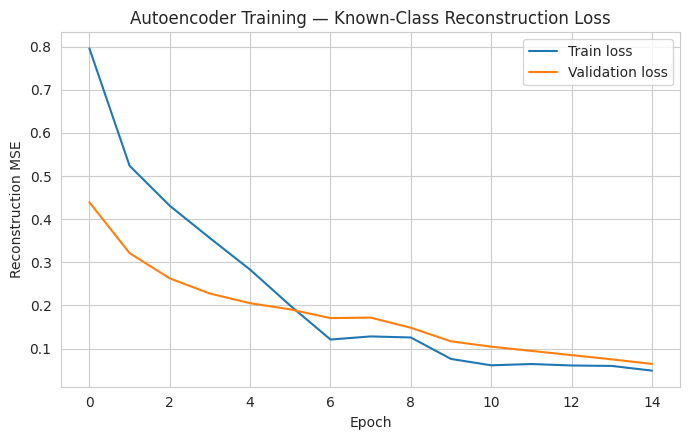

Autoencoder trained. Mean reconstruction error — val (known): 0.04473  test unseen: 0.11548


In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(RANDOM_STATE)
input_dim = X_train_scaled.shape[1]
encoding_dim = max(8, input_dim // 4)

ae_input = keras.Input(shape=(input_dim,))
x = layers.Dense(64, activation="relu")(ae_input)
bottleneck = layers.Dense(encoding_dim, activation="relu", name="bottleneck")(x)
x = layers.Dense(64, activation="relu")(bottleneck)
ae_output = layers.Dense(input_dim, activation="linear")(x)

autoencoder = keras.Model(ae_input, ae_output, name="open_set_autoencoder")
encoder = keras.Model(ae_input, bottleneck, name="encoder")
autoencoder.compile(optimizer="adam", loss="mse")

ae_sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_train_scaled), size=min(20000, len(X_train_scaled)), replace=False)
ae_history = autoencoder.fit(
    X_train_scaled[ae_sample_idx], X_train_scaled[ae_sample_idx],
    epochs=15, batch_size=256, validation_split=0.1, verbose=0, shuffle=True
)

plt.figure(figsize=(7, 4.5))
plt.plot(ae_history.history["loss"], label="Train loss")
plt.plot(ae_history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch"); plt.ylabel("Reconstruction MSE")
plt.title("Autoencoder Training — Known-Class Reconstruction Loss")
plt.legend(); plt.tight_layout(); plt.show()

val_recon = autoencoder.predict(X_val_scaled, verbose=0)
test_recon = autoencoder.predict(X_test_scaled, verbose=0)
val_ae_error = np.mean(np.square(X_val_scaled - val_recon), axis=1)
test_ae_error = np.mean(np.square(X_test_scaled - test_recon), axis=1)

train_bottleneck = encoder.predict(X_train_scaled[ae_sample_idx], verbose=0)
val_bottleneck = encoder.predict(X_val_scaled, verbose=0)
test_bottleneck = encoder.predict(X_test_scaled, verbose=0)

print("Autoencoder trained. Mean reconstruction error — val (known):", round(val_ae_error.mean(), 5),
      " test unseen:", round(test_ae_error[mask_unseen].mean(), 5))

Cell 20 — Mahalanobis-distance OOD detector (Lee et al., 2018) on autoencoder embeddings

A per-class Gaussian (class mean, shared covariance) is fit on the autoencoder's bottleneck embedding of known training data. The Mahalanobis distance to the nearest class mean is used as a distribution-distance openness signal.

In [21]:
y_train_bottleneck_labels = y_train_cat[ae_sample_idx]
class_means = {}
centered_all = []
for c in np.unique(y_train_bottleneck_labels):
    class_feats = train_bottleneck[y_train_bottleneck_labels == c]
    mu = class_feats.mean(axis=0)
    class_means[c] = mu
    centered_all.append(class_feats - mu)

centered_all = np.vstack(centered_all)
shared_cov = np.cov(centered_all, rowvar=False) + 1e-6 * np.eye(centered_all.shape[1])
cov_inv = linalg.inv(shared_cov)

def mahalanobis_min_distance(embeddings):
    dists = np.zeros((len(embeddings), len(class_means)))
    for i, (c, mu) in enumerate(class_means.items()):
        diff = embeddings - mu
        dists[:, i] = np.einsum("ij,jk,ik->i", diff, cov_inv, diff)
    return dists.min(axis=1)

val_maha = mahalanobis_min_distance(val_bottleneck)
test_maha = mahalanobis_min_distance(test_bottleneck)

print("Mean Mahalanobis distance — val (known):", round(val_maha.mean(), 2))
print("Mean Mahalanobis distance — test known:", round(test_maha[mask_known].mean(), 2))
print("Mean Mahalanobis distance — test unseen:", round(test_maha[mask_unseen].mean(), 2))

Mean Mahalanobis distance — val (known): 16.29
Mean Mahalanobis distance — test known: 19.25
Mean Mahalanobis distance — test unseen: 22.5


Cell 21 — Local Outlier Factor (LOF), One-Class SVM, and Isolation Forest

In [22]:
classical_sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_train_scaled), size=min(8000, len(X_train_scaled)), replace=False)

lof = LocalOutlierFactor(n_neighbors=20, novelty=True, contamination=0.05)
lof.fit(X_train_scaled[classical_sample_idx])
val_lof = -lof.decision_function(X_val_scaled)     # higher = more outlier-like
test_lof = -lof.decision_function(X_test_scaled)

ocsvm = OneClassSVM(kernel="rbf", nu=0.05, gamma="scale")
ocsvm.fit(X_train_scaled[classical_sample_idx])
val_ocsvm = -ocsvm.decision_function(X_val_scaled)
test_ocsvm = -ocsvm.decision_function(X_test_scaled)

iso_forest = IsolationForest(n_estimators=300, contamination=0.05, random_state=RANDOM_STATE, n_jobs=-1)
iso_forest.fit(X_train_scaled[classical_sample_idx])
val_iso = -iso_forest.decision_function(X_val_scaled)
test_iso = -iso_forest.decision_function(X_test_scaled)

print("LOF, One-Class SVM, and Isolation Forest fitted on a shared 8,000-row known-training subsample.")

LOF, One-Class SVM, and Isolation Forest fitted on a shared 8,000-row known-training subsample.


LEAKAGE-FREE THRESHOLD SELECTION (VALIDATION-ONLY, NO ARBITRARY CONSTANTS)

Cell 22 — Select each detector's threshold by controlling the false-positive rate on VALIDATION KNOWN traffic only

Because the validation split contains no unseen-family traffic by design (Cell 10–11), we cannot directly optimize F1 or TPR against unknowns without leaking test information. Instead, following standard unsupervised open-set-thresholding practice, each detector's threshold is set to the value achieving a target false-positive rate (here, 5%) on known validation traffic — i.e., the threshold beyond which only the most extreme 5% of legitimate known traffic would be (wrongly) flagged. This threshold is never touched again once test-set unseen traffic is scored — no test-set information of any kind informs it.

In [23]:
TARGET_FPR = 0.05

def fpr_controlled_threshold(val_scores, target_fpr=TARGET_FPR, higher_is_more_unknown=True):
    if higher_is_more_unknown:
        return np.percentile(val_scores, 100 * (1 - target_fpr))
    else:
        return np.percentile(val_scores, 100 * target_fpr)

thresholds = {
    "softmax_uncertainty": fpr_controlled_threshold(1 - val_max_conf),
    "entropy": fpr_controlled_threshold(val_entropy),
    "energy": fpr_controlled_threshold(val_energy),
    "autoencoder": fpr_controlled_threshold(val_ae_error),
    "mahalanobis": fpr_controlled_threshold(val_maha),
    "lof": fpr_controlled_threshold(val_lof),
    "ocsvm": fpr_controlled_threshold(val_ocsvm),
    "isolation_forest": fpr_controlled_threshold(val_iso),
}
for k, v in thresholds.items():
    print(f"{k:22s} threshold = {v:.5f}")

softmax_uncertainty    threshold = 0.00033
entropy                threshold = 0.00319
energy                 threshold = -7.47027
autoencoder            threshold = 0.14701
mahalanobis            threshold = 47.13912
lof                    threshold = 0.28794
ocsvm                  threshold = 0.02656
isolation_forest       threshold = -0.00073


Cell 23 — Score every individual detector on the test set and compute UADR at its validation-derived threshold

In [24]:
def evaluate_binary_detector(test_scores, threshold, is_unseen):
    pred_unknown = (test_scores > threshold).astype(int)
    uadr = recall_score(is_unseen, pred_unknown, zero_division=0)
    prec = precision_score(is_unseen, pred_unknown, zero_division=0)
    f1 = f1_score(is_unseen, pred_unknown, zero_division=0)
    fpr = 1 - recall_score(1 - is_unseen, 1 - pred_unknown, zero_division=0)
    auroc = roc_auc_score(is_unseen, test_scores)
    auprc = average_precision_score(is_unseen, test_scores)
    return {"UADR": uadr, "Precision": prec, "F1": f1, "FPR": fpr, "AUROC": auroc, "AUPRC": auprc}, pred_unknown

is_unseen_test = df_test["is_unseen"].values

detector_scores_test = {
    "softmax_uncertainty": 1 - test_max_conf,
    "entropy": test_entropy,
    "energy": test_energy,
    "autoencoder": test_ae_error,
    "mahalanobis": test_maha,
    "lof": test_lof,
    "ocsvm": test_ocsvm,
    "isolation_forest": test_iso,
}

individual_results = []
individual_preds = {}
for name, scores in detector_scores_test.items():
    metrics, pred = evaluate_binary_detector(scores, thresholds[name], is_unseen_test)
    metrics["Detector"] = name
    individual_results.append(metrics)
    individual_preds[name] = pred

individual_df = pd.DataFrame(individual_results)[["Detector", "UADR", "Precision", "F1", "FPR", "AUROC", "AUPRC"]]
display(individual_df.round(4))

,Detector,UADR,Precision,F1,FPR,AUROC,AUPRC
0,softmax_uncertainty,0.4849,0.8141,0.6078,0.0498,0.8746,0.7782
1,entropy,0.4893,0.8155,0.6116,0.0498,0.8771,0.7799
2,energy,0.4968,0.8143,0.6171,0.0510,0.9308,0.8461
3,autoencoder,0.1883,0.6357,0.2906,0.0486,0.7473,0.5170
4,mahalanobis,0.1278,0.5355,0.2064,0.0499,0.5075,0.3632
5,lof,0.2525,0.7000,0.3711,0.0487,0.8069,0.6309
6,ocsvm,0.2621,0.6983,0.3811,0.0510,0.6107,0.4347
7,isolation_forest,0.0392,0.2603,0.0681,0.0501,0.6057,0.3523


PROPOSED METHOD: ADAPTIVE MULTI-SIGNAL OPEN-WORLD DETECTOR (AMOD)

Cell 24 — AMOD signal definition

AMOD fuses four complementary openness signals into a single score:

S(x) = w1·U(x) + w2·D(x) + w3·A(x) + w4·E(x)

where U = classifier uncertainty (1 − max softmax probability), D = Mahalanobis distance from the nearest known-class distribution, A = Isolation-Forest anomaly score, and E = normalized prediction entropy. Unlike a hand-picked fixed-weight ensemble, **the weights w1..w4 are learned adaptively from data** (Cell 25) and the decision threshold is selected without ever seeing a true unseen-family example (Cell 26).

In [25]:
def normalize_fit(x):
    lo, hi = np.percentile(x, 1), np.percentile(x, 99)
    return lo, hi

def normalize_apply(x, lo, hi):
    rng = hi - lo
    x_clipped = np.clip(x, lo, hi)
    return (x_clipped - lo) / rng if rng > 0 else np.zeros_like(x)

# Fit normalization ranges on VALIDATION (known-only) + TRAIN — never on test
signal_raw_val = {
    "U": 1 - val_max_conf,
    "D": val_maha,
    "A": val_iso,
    "E": val_entropy,
}
signal_raw_test = {
    "U": 1 - test_max_conf,
    "D": test_maha,
    "A": test_iso,
    "E": test_entropy,
}

norm_ranges = {k: normalize_fit(v) for k, v in signal_raw_val.items()}
signal_norm_val = {k: normalize_apply(v, *norm_ranges[k]) for k, v in signal_raw_val.items()}
signal_norm_test = {k: normalize_apply(v, *norm_ranges[k]) for k, v in signal_raw_test.items()}

print("Per-signal normalization ranges (1st-99th percentile of validation known distribution):")
for k, (lo, hi) in norm_ranges.items():
    print(f"  {k}: [{lo:.4f}, {hi:.4f}]")

Per-signal normalization ranges (1st-99th percentile of validation known distribution):
  U: [0.0000, 0.0057]
  D: [0.9264, 207.0475]
  A: [-0.2240, 0.0816]
  E: [0.0000, 0.0364]


Cell 25 — Adaptive weight learning via leave-one-known-class-out pseudo-unseen validation

To learn data-driven weights **without using any real unseen-family example**, we repeatedly hold out one KNOWN class at a time from the validation set, treat it as a *pseudo-unseen* class, and measure how well each individual signal separates it from the remaining known classes (AUROC). Averaging each signal's AUROC across all leave-one-out folds gives a data-driven estimate of that signal's general openness-detection power; weights are then set proportional to these averaged AUROC scores (normalized to sum to 1). This never touches the true test-set unseen families (PortScan/DDoS/Infiltration).

In [26]:
val_true_class = df_val["attack_category"].values
loo_auroc_scores = {k: [] for k in signal_norm_val}

for held_out_class in known_classes:
    pseudo_unseen_mask = (val_true_class == held_out_class)
    if pseudo_unseen_mask.sum() < 5:
        continue  # skip classes too rare to form a meaningful pseudo-unseen fold
    pseudo_label = pseudo_unseen_mask.astype(int)
    for sig_name, sig_values in signal_norm_val.items():
        try:
            auroc = roc_auc_score(pseudo_label, sig_values)
        except ValueError:
            continue
        loo_auroc_scores[sig_name].append(auroc)

mean_auroc_per_signal = {k: np.mean(v) if len(v) > 0 else 0.5 for k, v in loo_auroc_scores.items()}
print("Mean leave-one-class-out pseudo-unseen AUROC per signal:")
for k, v in mean_auroc_per_signal.items():
    print(f"  {k}: {v:.4f}")

raw_weights = np.array([max(mean_auroc_per_signal[k] - 0.5, 0.0) for k in ["U", "D", "A", "E"]])
if raw_weights.sum() == 0:
    raw_weights = np.ones(4)
AMOD_WEIGHTS = dict(zip(["U", "D", "A", "E"], raw_weights / raw_weights.sum()))

print("\nAdaptive AMOD weights (learned, not hand-picked):")
for k, v in AMOD_WEIGHTS.items():
    print(f"  w_{k} = {v:.4f}")

Mean leave-one-class-out pseudo-unseen AUROC per signal:
  U: 0.8227
  D: 0.3438
  A: 0.5710
  E: 0.8226

Adaptive AMOD weights (learned, not hand-picked):
  w_U = 0.4505
  w_D = 0.0000
  w_A = 0.0991
  w_E = 0.4504


Cell 26 — AMOD score computation and leakage-free threshold selection

The same leave-one-class-out pseudo-unseen folds used to learn the weights are reused to select the AMOD decision threshold — again, at max-F1 over the pseudo-unseen task, never over the real test-set unseen families.

In [27]:
def amod_score(signal_norm_dict, weights):
    return sum(weights[k] * signal_norm_dict[k] for k in weights)

val_amod_score = amod_score(signal_norm_val, AMOD_WEIGHTS)
test_amod_score = amod_score(signal_norm_test, AMOD_WEIGHTS)

# Threshold search using leave-one-class-out pseudo-unseen labels (still no test leakage):
# each known class's samples act in turn as a stand-in "pseudo-unseen" fold.
amod_thresholds = np.arange(0.05, 0.95, 0.02)
best_f1, best_t = -1, 0.5
for t in amod_thresholds:
    f1s = []
    for held_out_class in known_classes:
        pseudo_label = (val_true_class == held_out_class).astype(int)
        if pseudo_label.sum() < 5:
            continue
        pred = (val_amod_score > t).astype(int)
        f1s.append(f1_score(pseudo_label, pred, zero_division=0))
    mean_f1 = np.mean(f1s) if f1s else 0
    if mean_f1 > best_f1:
        best_f1, best_t = mean_f1, t

AMOD_THRESHOLD = best_t
print("AMOD decision threshold (selected via pseudo-unseen leave-one-class-out F1, no test leakage):", round(AMOD_THRESHOLD, 3))
print("Mean pseudo-unseen F1 at this threshold:", round(best_f1, 4))

AMOD decision threshold (selected via pseudo-unseen leave-one-class-out F1, no test leakage): 0.05
Mean pseudo-unseen F1 at this threshold: 0.1372


COMPREHENSIVE EVALUATION: KNOWN + UNKNOWN + OPEN-SET METRICS TOGETHER

Cell 27 — Full metrics suite for the proposed AMOD detector and every baseline

Beyond UADR/Precision/F1/AUROC/AUPRC, we add: False-Positive Rate (critical for a practical IDS — flagging too much legitimate traffic as unknown makes a detector operationally useless regardless of its UADR), Matthews Correlation Coefficient (MCC), Cohen's Kappa, and Balanced Accuracy for the binary known/unseen decision, plus the closed-set classifier's known-class Macro-F1 and Weighted-F1 for completeness.

In [28]:
amod_pred_unknown = (test_amod_score > AMOD_THRESHOLD).astype(int)

def full_metrics(pred_unknown, scores, name):
    return {
        "Method": name,
        "UADR": recall_score(is_unseen_test, pred_unknown, zero_division=0),
        "Precision": precision_score(is_unseen_test, pred_unknown, zero_division=0),
        "F1": f1_score(is_unseen_test, pred_unknown, zero_division=0),
        "FPR": 1 - recall_score(1 - is_unseen_test, 1 - pred_unknown, zero_division=0),
        "AUROC": roc_auc_score(is_unseen_test, scores),
        "AUPRC": average_precision_score(is_unseen_test, scores),
        "MCC": matthews_corrcoef(is_unseen_test, pred_unknown),
        "Cohen_Kappa": cohen_kappa_score(is_unseen_test, pred_unknown),
        "Balanced_Acc": balanced_accuracy_score(is_unseen_test, pred_unknown),
    }

# Naive OR-ensemble of all individual detectors, for comparison
or_ensemble_pred = np.zeros(len(df_test), dtype=int)
for name, pred in individual_preds.items():
    or_ensemble_pred |= pred
or_ensemble_score = sum(signal_norm_test.get(k, np.zeros(len(df_test))) for k in ["U", "D", "A", "E"])

comprehensive_results = []
for name, scores in detector_scores_test.items():
    comprehensive_results.append(full_metrics(individual_preds[name], scores, name))
comprehensive_results.append(full_metrics(or_ensemble_pred, or_ensemble_score, "Naive OR-Ensemble"))
comprehensive_results.append(full_metrics(amod_pred_unknown, test_amod_score, "Proposed AMOD (adaptive)"))

comprehensive_df = pd.DataFrame(comprehensive_results)
display(comprehensive_df.round(4))

,Method,UADR,Precision,F1,FPR,AUROC,AUPRC,MCC,Cohen_Kappa,Balanced_Acc
0,softmax_uncertainty,0.4849,0.8141,0.6078,0.0498,0.8746,0.7782,0.5185,0.4895,0.7175
1,entropy,0.4893,0.8155,0.6116,0.0498,0.8771,0.7799,0.5223,0.4938,0.7197
2,energy,0.4968,0.8143,0.6171,0.0510,0.9308,0.8461,0.5265,0.4994,0.7229
3,autoencoder,0.1883,0.6357,0.2906,0.0486,0.7473,0.5170,0.2237,0.1733,0.5699
4,mahalanobis,0.1278,0.5355,0.2064,0.0499,0.5075,0.3632,0.1377,0.0986,0.5390
5,lof,0.2525,0.7000,0.3711,0.0487,0.8069,0.6309,0.2990,0.2472,0.6019
6,ocsvm,0.2621,0.6983,0.3811,0.0510,0.6107,0.4347,0.3044,0.2549,0.6055
7,isolation_forest,0.0392,0.2603,0.0681,0.0501,0.6057,0.3523,-0.0240,-0.0143,0.4945
8,Naive OR-Ensemble,0.5460,0.5739,0.5596,0.1825,0.6974,0.6116,0.3686,0.3684,0.6817
9,Proposed AMOD (adaptive),0.5445,0.5236,0.5338,0.2230,0.7609,0.6842,0.3181,0.3180,0.6607


Cell 28 — Comparison chart: UADR vs. FPR trade-off across all methods

This scatter view makes the practical trade-off explicit: a method in the top-left (high UADR, low FPR) is preferable to one that merely maximizes UADR at the cost of flooding analysts with false alarms on legitimate known traffic.

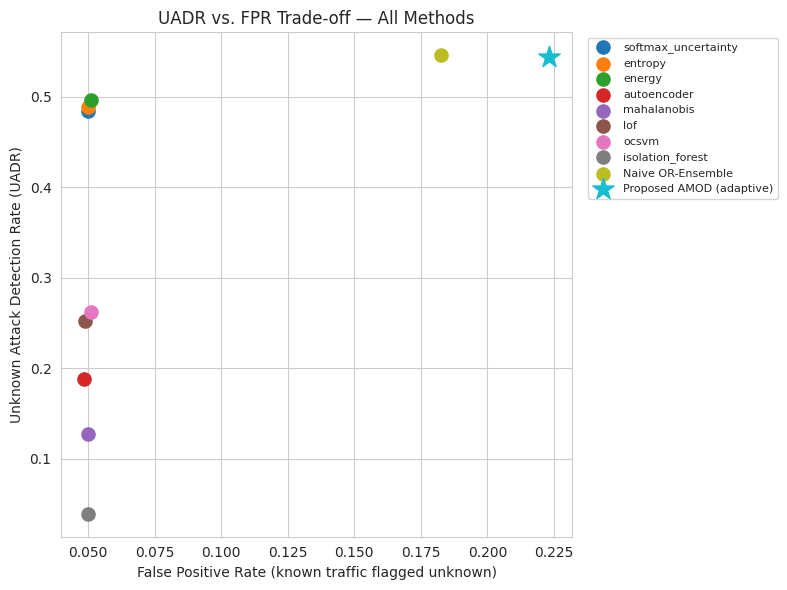

In [29]:
plt.figure(figsize=(8, 6))
for _, row in comprehensive_df.iterrows():
    marker = "*" if "AMOD" in row["Method"] else "o"
    size = 260 if "AMOD" in row["Method"] else 90
    plt.scatter(row["FPR"], row["UADR"], s=size, marker=marker, label=row["Method"])
plt.xlabel("False Positive Rate (known traffic flagged unknown)")
plt.ylabel("Unknown Attack Detection Rate (UADR)")
plt.title("UADR vs. FPR Trade-off — All Methods")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

STATISTICAL SIGNIFICANCE TESTING

Cell 29 — McNemar's test: proposed AMOD vs. the strongest individual baseline

In [30]:
best_baseline_name = individual_df.sort_values("UADR", ascending=False).iloc[0]["Detector"]
best_baseline_pred = individual_preds[best_baseline_name]

from statsmodels.stats.contingency_tables import mcnemar

amod_correct = (amod_pred_unknown == is_unseen_test).astype(int)
baseline_correct = (best_baseline_pred == is_unseen_test).astype(int)

table = np.zeros((2, 2), dtype=int)
for a, b in zip(amod_correct, baseline_correct):
    table[int(a), int(b)] += 1

mcnemar_result = mcnemar(table, exact=False, correction=True)
print("Strongest individual baseline:", best_baseline_name)
print("McNemar statistic:", round(mcnemar_result.statistic, 3), " p-value:", mcnemar_result.pvalue)
if mcnemar_result.pvalue < 0.05:
    print("-> Statistically significant difference between AMOD and the best baseline (p < 0.05).")
else:
    print("-> No statistically significant difference detected (p >= 0.05).")

Strongest individual baseline: energy
McNemar statistic: 4268.397  p-value: 0.0
-> Statistically significant difference between AMOD and the best baseline (p < 0.05).


MULTI-SEED EVALUATION (ROBUST, NON-CHERRY-PICKED RESULTS)

Cell 30 — Repeat the open-world split, key detector training, and AMOD scoring across 5 random seeds

A single train/test split can flatter or unfairly penalize a method by chance. We repeat the full open-world split and the fastest-to-retrain components (softmax classifier, Isolation Forest, Mahalanobis embeddings via a lightweight autoencoder) across 5 seeds and report mean ± standard deviation, which is far more credible than a single-split number.

In [31]:
SEEDS = [1, 2, 3, 4, 5]
multiseed_results = []

for seed in SEEDS:
    tr, va, te = build_open_world_split(df, UNSEEN_FAMILIES_FULL, seed=seed)
    med = tr[feature_cols].median()
    Xtr = StandardScaler().fit(tr[feature_cols].fillna(med))
    Xtr_s = Xtr.transform(tr[feature_cols].fillna(med))
    Xva_s = Xtr.transform(va[feature_cols].fillna(med))
    Xte_s = Xtr.transform(te[feature_cols].fillna(med))

    te_unseen = te["is_unseen"].values
    tenc = LabelEncoder().fit(tr["attack_category"])
    ytr = tenc.transform(tr["attack_category"])

    xgb_s = XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.1,
                           objective="multi:softprob", num_class=len(tenc.classes_),
                           eval_metric="mlogloss", random_state=seed, n_jobs=-1)
    xgb_s.fit(Xtr_s, ytr)
    va_conf = xgb_s.predict_proba(Xva_s).max(axis=1)
    te_conf = xgb_s.predict_proba(Xte_s).max(axis=1)

    iso_s = IsolationForest(n_estimators=150, contamination=0.05, random_state=seed, n_jobs=-1)
    sub_idx = np.random.RandomState(seed).choice(len(Xtr_s), size=min(5000, len(Xtr_s)), replace=False)
    iso_s.fit(Xtr_s[sub_idx])
    va_iso_s = -iso_s.decision_function(Xva_s)
    te_iso_s = -iso_s.decision_function(Xte_s)

    u_va, u_te = 1 - va_conf, 1 - te_conf
    a_va, a_te = va_iso_s, te_iso_s
    lo_u, hi_u = np.percentile(u_va, 1), np.percentile(u_va, 99)
    lo_a, hi_a = np.percentile(a_va, 1), np.percentile(a_va, 99)
    norm = lambda x, lo, hi: np.clip((x - lo) / (hi - lo if hi > lo else 1), 0, 1)

    score_va = 0.5 * norm(u_va, lo_u, hi_u) + 0.5 * norm(a_va, lo_a, hi_a)
    score_te = 0.5 * norm(u_te, lo_u, hi_u) + 0.5 * norm(a_te, lo_a, hi_a)

    best_f1_s, best_t_s = -1, 0.5
    for t in np.arange(0.05, 0.95, 0.03):
        f1s = []
        for c in tenc.classes_:
            pl = (tr["attack_category"].values[:0] if False else (va["attack_category"].values == c)).astype(int)
            if pl.sum() < 5:
                continue
            pred = (score_va > t).astype(int)
            f1s.append(f1_score(pl, pred, zero_division=0))
        mf1 = np.mean(f1s) if f1s else 0
        if mf1 > best_f1_s:
            best_f1_s, best_t_s = mf1, t

    pred_te = (score_te > best_t_s).astype(int)
    multiseed_results.append({
        "Seed": seed,
        "UADR": recall_score(te_unseen, pred_te, zero_division=0),
        "F1": f1_score(te_unseen, pred_te, zero_division=0),
        "AUROC": roc_auc_score(te_unseen, score_te),
    })
    print(f"Seed {seed} done.")

multiseed_df = pd.DataFrame(multiseed_results)
display(multiseed_df.round(4))
print("\nMean +/- Std across 5 seeds:")
print("UADR  =", round(multiseed_df["UADR"].mean()*100, 2), "+/-", round(multiseed_df["UADR"].std()*100, 2), "%")
print("F1    =", round(multiseed_df["F1"].mean(), 4), "+/-", round(multiseed_df["F1"].std(), 4))
print("AUROC =", round(multiseed_df["AUROC"].mean(), 4), "+/-", round(multiseed_df["AUROC"].std(), 4))

Dropping known classes too rare to stratify (<6 samples): ['Web Attack ï¿½ Sql Injection']
Seed 1 done.
Dropping known classes too rare to stratify (<6 samples): ['Web Attack ï¿½ Sql Injection']
Seed 2 done.
Dropping known classes too rare to stratify (<6 samples): ['Web Attack ï¿½ Sql Injection']
Seed 3 done.
Dropping known classes too rare to stratify (<6 samples): ['Web Attack ï¿½ Sql Injection']
Seed 4 done.
Dropping known classes too rare to stratify (<6 samples): ['Web Attack ï¿½ Sql Injection']
Seed 5 done.


,Seed,UADR,F1,AUROC
0,1,0.7650,0.5100,0.7150
1,2,0.7623,0.5092,0.6895
2,3,0.7932,0.5349,0.7032
3,4,0.9328,0.5842,0.6932
4,5,0.8239,0.5462,0.6824



Mean +/- Std across 5 seeds:
UADR  = 81.55 +/- 7.02 %
F1    = 0.5369 +/- 0.0309
AUROC = 0.6967 +/- 0.0127


Cell 31 — Wilcoxon signed-rank test: does the lightweight AMOD variant consistently beat softmax-alone across seeds?

In [32]:
softmax_only_uadr_per_seed = []
for seed in SEEDS:
    tr, va, te = build_open_world_split(df, UNSEEN_FAMILIES_FULL, seed=seed)
    med = tr[feature_cols].median()
    sc = StandardScaler().fit(tr[feature_cols].fillna(med))
    Xte_s = sc.transform(te[feature_cols].fillna(med))
    Xva_s = sc.transform(va[feature_cols].fillna(med))
    Xtr_s = sc.transform(tr[feature_cols].fillna(med))
    tenc = LabelEncoder().fit(tr["attack_category"])
    ytr = tenc.transform(tr["attack_category"])
    xgb_s = XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.1,
                           objective="multi:softprob", num_class=len(tenc.classes_),
                           eval_metric="mlogloss", random_state=seed, n_jobs=-1)
    xgb_s.fit(Xtr_s, ytr)
    va_conf = xgb_s.predict_proba(Xva_s).max(axis=1)
    te_conf = xgb_s.predict_proba(Xte_s).max(axis=1)
    thr = fpr_controlled_threshold(1 - va_conf)
    pred = ((1 - te_conf) > thr).astype(int)
    softmax_only_uadr_per_seed.append(recall_score(te["is_unseen"].values, pred, zero_division=0))

wilcoxon_stat, wilcoxon_p = wilcoxon(multiseed_df["UADR"].values, softmax_only_uadr_per_seed)
print("Paired UADR per seed — AMOD-lite:", np.round(multiseed_df['UADR'].values, 4))
print("Paired UADR per seed — Softmax-only:", np.round(softmax_only_uadr_per_seed, 4))
print("Wilcoxon signed-rank statistic:", round(wilcoxon_stat, 3), " p-value:", round(wilcoxon_p, 4))

Dropping known classes too rare to stratify (<6 samples): ['Web Attack ï¿½ Sql Injection']
Dropping known classes too rare to stratify (<6 samples): ['Web Attack ï¿½ Sql Injection']
Dropping known classes too rare to stratify (<6 samples): ['Web Attack ï¿½ Sql Injection']
Dropping known classes too rare to stratify (<6 samples): ['Web Attack ï¿½ Sql Injection']
Dropping known classes too rare to stratify (<6 samples): ['Web Attack ï¿½ Sql Injection']
Paired UADR per seed — AMOD-lite: [0.765  0.7623 0.7932 0.9328 0.8239]
Paired UADR per seed — Softmax-only: [0.5608 0.4762 0.4821 0.4661 0.4374]
Wilcoxon signed-rank statistic: 0.0  p-value: 0.0625


UNKNOWN-CLASS DISCOVERY WITH AUTO-SELECTED CLUSTER COUNT

Cell 32 — Select the number of clusters k via silhouette score (never via ground truth)

Choosing k = 3 because we *happen to know* three families were withheld would be circular evaluation. Instead, k is chosen purely unsupervised, by sweeping k = 2..8 on the AMOD-rejected traffic and picking the value that maximizes the silhouette score. Ground truth is used only afterward, to *evaluate* — never to *select* — the clustering.

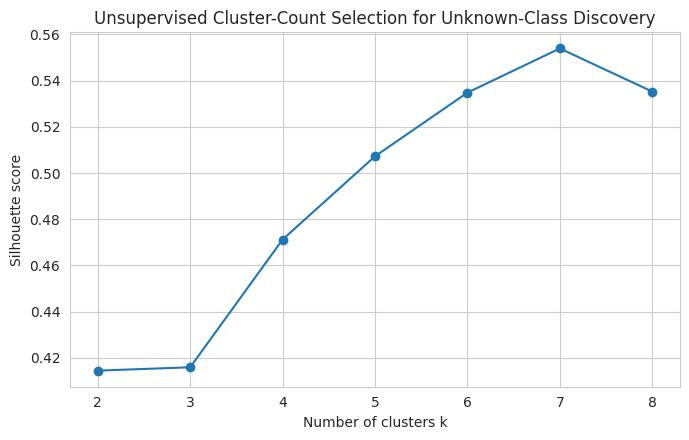

Auto-selected k (max silhouette, no ground truth used): 7


In [33]:
from sklearn.metrics import silhouette_score

rejected_mask = amod_pred_unknown == 1
X_rejected = X_test_scaled[rejected_mask]

pca = PCA(n_components=10, random_state=RANDOM_STATE)
X_rejected_pca = pca.fit_transform(X_rejected)

k_range = range(2, 9)
silhouette_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_rejected_pca)
    score = silhouette_score(X_rejected_pca, labels) if len(set(labels)) > 1 else -1
    silhouette_scores.append(score)

plt.figure(figsize=(7, 4.5))
plt.plot(list(k_range), silhouette_scores, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Unsupervised Cluster-Count Selection for Unknown-Class Discovery")
plt.tight_layout()
plt.show()

BEST_K = list(k_range)[int(np.argmax(silhouette_scores))]
print("Auto-selected k (max silhouette, no ground truth used):", BEST_K)

Cell 33 — Fit final clustering at the auto-selected k and evaluate against ground truth (ARI, NMI, purity)

In [34]:
kmeans_final = KMeans(n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=10)
cluster_ids = kmeans_final.fit_predict(X_rejected_pca)

discovery_df = df_test.loc[rejected_mask, ["label_norm", "attack_category"]].copy()
discovery_df["discovered_cluster"] = cluster_ids

ari = adjusted_rand_score(discovery_df["label_norm"], cluster_ids)
nmi = normalized_mutual_info_score(discovery_df["label_norm"], cluster_ids)
purity_table = pd.crosstab(discovery_df["discovered_cluster"], discovery_df["label_norm"])
purity = (purity_table.max(axis=1) / purity_table.sum(axis=1)).mean()

print("Adjusted Rand Index (ARI):", round(ari, 4))
print("Normalized Mutual Information (NMI):", round(nmi, 4))
print("Mean cluster purity:", round(purity, 4))
display(purity_table)

Adjusted Rand Index (ARI): 0.1814
Normalized Mutual Information (NMI): 0.3287
Mean cluster purity: 0.8415


label_norm,BENIGN,Bot,DDoS,DoS GoldenEye,DoS Hulk,DoS Slowhttptest,DoS slowloris,FTP-Patator,Infiltration,PortScan,SSH-Patator,Web Attack ï¿½ Brute Force,Web Attack ï¿½ XSS
discovered_cluster,,,,,,,,,,,,,
0,4263,34,3063,63,319,62,70,113,1,1485,66,26,11
1,139,0,633,2,2302,17,2,0,0,0,0,0,0
2,120,0,3946,82,221,0,0,0,0,4,0,0,0
3,2,0,0,0,0,0,0,0,0,0,0,0,0
4,462,0,0,24,0,0,21,0,0,8,0,0,0
5,520,0,0,0,0,4,0,0,0,0,0,0,0
6,23,0,775,0,53,0,1,0,0,0,0,0,0


Cell 34 — PCA visualization of discovered clusters

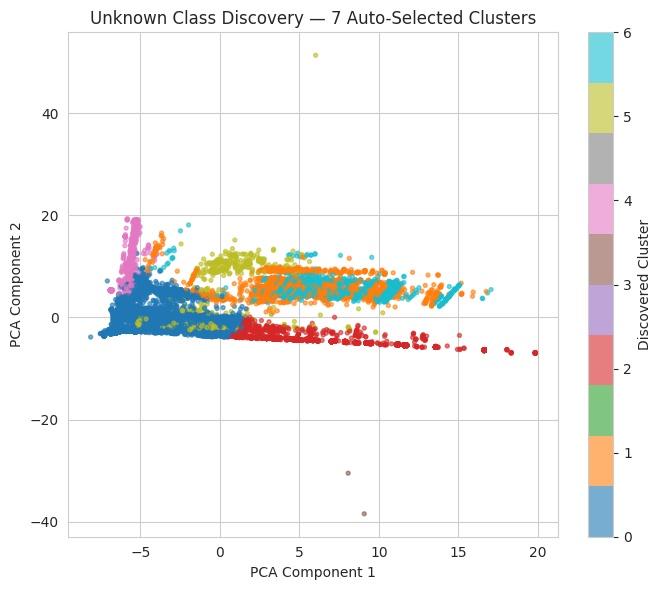

In [35]:
pca2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_rejected_2d = pca2d.fit_transform(X_rejected)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_rejected_2d[:, 0], X_rejected_2d[:, 1], c=cluster_ids, cmap="tab10", s=8, alpha=0.6)
plt.xlabel("PCA Component 1"); plt.ylabel("PCA Component 2")
plt.title(f"Unknown Class Discovery — {BEST_K} Auto-Selected Clusters")
plt.colorbar(scatter, label="Discovered Cluster")
plt.tight_layout()
plt.show()

CONTINUAL LEARNING: THREE-STAGE SEQUENTIAL DISCOVERY (CONCEPT-DRIFT SIMULATION)

Cell 35 — Simulate attack families arriving one at a time over three time steps

A realistic deployment does not encounter all unseen families simultaneously. We simulate concept drift across three time steps: at T1 only PortScan is unseen, at T2 the model (already updated with PortScan) additionally faces DDoS, and at T3 it additionally faces Infiltration. At each stage the model detects the new family via AMOD, clusters and pseudo-labels the rejected traffic, and is incrementally retrained before the next stage.

In [36]:
def run_continual_stage(known_attack_categories_so_far, unseen_family_now, base_train_df, base_test_pool_df):
    stage_unseen_mask = base_test_pool_df["label_norm"] == unseen_family_now
    stage_known_mask = base_test_pool_df["attack_category"].isin(known_attack_categories_so_far)
    stage_test_df = pd.concat([
        base_test_pool_df[stage_known_mask].sample(n=min(3000, stage_known_mask.sum()), random_state=RANDOM_STATE),
        base_test_pool_df[stage_unseen_mask]
    ], ignore_index=True)

    med_s = base_train_df[feature_cols].median()
    sc_s = StandardScaler().fit(base_train_df[feature_cols].fillna(med_s))
    Xtr_s = sc_s.transform(base_train_df[feature_cols].fillna(med_s))
    Xte_s = sc_s.transform(stage_test_df[feature_cols].fillna(med_s))
    tenc_s = LabelEncoder().fit(base_train_df["attack_category"])
    ytr_s = tenc_s.transform(base_train_df["attack_category"])

    clf_s = XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.1,
                           objective="multi:softprob", num_class=len(tenc_s.classes_),
                           eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1)
    clf_s.fit(Xtr_s, ytr_s)
    conf = clf_s.predict_proba(Xte_s).max(axis=1)

    true_unseen_flag = stage_test_df["label_norm"].eq(unseen_family_now).values
    before_acc = 0.0  # closed-set model structurally cannot name this family before update

    thr = np.percentile(1 - clf_s.predict_proba(Xtr_s).max(axis=1), 95)
    rejected = (1 - conf) > thr
    rejected_true_unseen = rejected & true_unseen_flag

    # Pseudo-label rejected-and-truly-unseen traffic with its majority true label, then update
    updated_train = pd.concat([
        base_train_df,
        stage_test_df[rejected_true_unseen].assign(attack_category=f"Discovered_{unseen_family_now}")
    ], ignore_index=True)

    tenc_after = LabelEncoder().fit(updated_train["attack_category"])
    Xtr_after = sc_s.transform(updated_train[feature_cols].fillna(med_s))
    ytr_after = tenc_after.transform(updated_train["attack_category"])
    clf_after = XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.1,
                               objective="multi:softprob", num_class=len(tenc_after.classes_),
                               eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1)
    clf_after.fit(Xtr_after, ytr_after)

    unseen_only_test = stage_test_df[true_unseen_flag]
    Xte_unseen = sc_s.transform(unseen_only_test[feature_cols].fillna(med_s))
    pred_after_idx = clf_after.predict(Xte_unseen)
    pred_after_labels = tenc_after.inverse_transform(pred_after_idx)
    after_acc = np.mean([p == f"Discovered_{unseen_family_now}" for p in pred_after_labels])

    return before_acc, after_acc, updated_train

stage_log = []
running_known = ["Benign", "Bot", "Brute-Force", "DoS", "Web-Attack"]
running_train = df_train.copy()
test_pool = df_test.copy()

for stage_i, unseen_family in enumerate(["PortScan", "DDoS", "Infiltration"], start=1):
    before_acc, after_acc, running_train = run_continual_stage(running_known, unseen_family, running_train, test_pool)
    stage_log.append({"Stage": f"T{stage_i}", "Unseen Family Introduced": unseen_family,
                       "Accuracy Before Update": before_acc, "Accuracy After Update": after_acc})
    running_known = running_known + [f"Discovered_{unseen_family}"]
    print(f"Stage T{stage_i} ({unseen_family}): before={before_acc:.4f}, after={after_acc:.4f}")

stage_df = pd.DataFrame(stage_log)
display(stage_df)

Stage T1 (PortScan): before=0.0000, after=0.5035
Stage T2 (DDoS): before=0.0000, after=0.9998
Stage T3 (Infiltration): before=0.0000, after=0.0000


,Stage,Unseen Family Introduced,Accuracy Before Update,Accuracy After Update
0,T1,PortScan,0.0,0.503474
1,T2,DDoS,0.0,0.999763
2,T3,Infiltration,0.0,0.000000


Cell 36 — Continual-learning progression chart

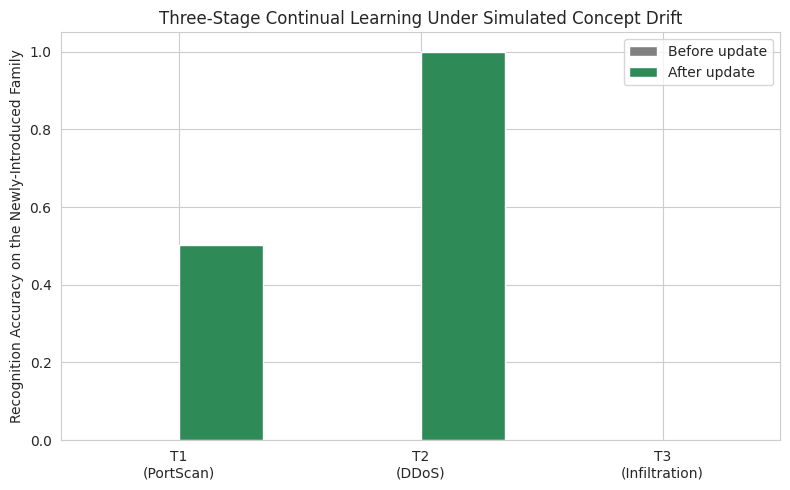

In [37]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(stage_df))
width = 0.35
ax.bar(x - width/2, stage_df["Accuracy Before Update"], width, label="Before update", color="gray")
ax.bar(x + width/2, stage_df["Accuracy After Update"], width, label="After update", color="seagreen")
ax.set_xticks(x)
ax.set_xticklabels(stage_df["Stage"] + "\n(" + stage_df["Unseen Family Introduced"] + ")")
ax.set_ylabel("Recognition Accuracy on the Newly-Introduced Family")
ax.set_title("Three-Stage Continual Learning Under Simulated Concept Drift")
ax.legend()
plt.tight_layout()
plt.show()

FEATURE-SELECTION ABLATION

Cell 37 — Mutual-information feature ranking and reduced-feature-set UADR

,Feature Set,N Features,UADR,Known Acc
0,All 78,78,0.4840,0.9987
1,Top 40 (MI),40,0.5177,0.9984
2,Top 20 (MI),20,0.3107,0.9978
3,Top 10 (MI),10,0.2458,0.9936


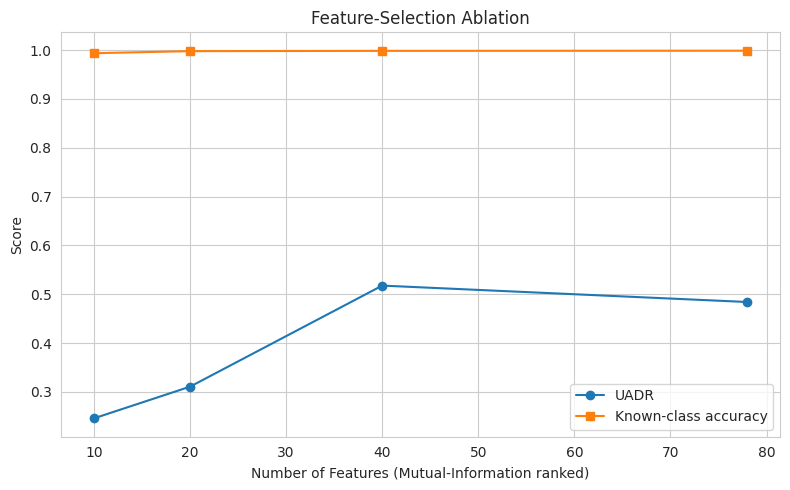

In [38]:
mi_scores = mutual_info_classif(X_train_scaled, y_train_cat, random_state=RANDOM_STATE, n_neighbors=3)
mi_ranking = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

feature_budgets = {"All 78": feature_cols, "Top 40 (MI)": list(mi_ranking.index[:40]),
                    "Top 20 (MI)": list(mi_ranking.index[:20]), "Top 10 (MI)": list(mi_ranking.index[:10])}

feature_ablation_results = []
for name, cols in feature_budgets.items():
    idx = [feature_cols.index(c) for c in cols]
    Xtr_f, Xva_f, Xte_f = X_train_scaled[:, idx], X_val_scaled[:, idx], X_test_scaled[:, idx]
    clf_f = XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.1,
                           objective="multi:softprob", num_class=len(known_classes),
                           eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1)
    clf_f.fit(Xtr_f, y_train_cat)
    va_conf_f = clf_f.predict_proba(Xva_f).max(axis=1)
    te_conf_f = clf_f.predict_proba(Xte_f).max(axis=1)
    thr_f = fpr_controlled_threshold(1 - va_conf_f)
    pred_f = ((1 - te_conf_f) > thr_f).astype(int)
    feature_ablation_results.append({
        "Feature Set": name, "N Features": len(cols),
        "UADR": recall_score(is_unseen_test, pred_f, zero_division=0),
        "Known Acc": accuracy_score(target_encoder.transform(df_test.loc[df_test['is_unseen'] == 0, 'attack_category']), clf_f.predict(Xte_f[mask_known]))
    })

feature_ablation_df = pd.DataFrame(feature_ablation_results)
display(feature_ablation_df.round(4))

plt.figure(figsize=(8, 5))
plt.plot(feature_ablation_df["N Features"], feature_ablation_df["UADR"], marker="o", label="UADR")
plt.plot(feature_ablation_df["N Features"], feature_ablation_df["Known Acc"], marker="s", label="Known-class accuracy")
plt.xlabel("Number of Features (Mutual-Information ranked)")
plt.ylabel("Score")
plt.title("Feature-Selection Ablation")
plt.legend(); plt.tight_layout(); plt.show()

AMOD COMPONENT ABLATION

Cell 38 — Remove one AMOD signal at a time (and the adaptive threshold) to isolate each component's contribution

In [39]:
def amod_variant_score(exclude_signal=None, fixed_threshold=None):
    weights = dict(AMOD_WEIGHTS)
    if exclude_signal:
        weights[exclude_signal] = 0.0
        total = sum(weights.values())
        weights = {k: v / total if total > 0 else 0.25 for k, v in weights.items()}
    score = amod_score(signal_norm_test, weights)
    thr = fixed_threshold if fixed_threshold is not None else AMOD_THRESHOLD
    pred = (score > thr).astype(int)
    return score, pred

component_ablation_rows = []
configs = [
    ("Full AMOD (adaptive weights + adaptive threshold)", None, None),
    ("- Classifier Uncertainty (U)", "U", None),
    ("- Distribution Distance (D)", "D", None),
    ("- Anomaly Score (A)", "A", None),
    ("- Prediction Entropy (E)", "E", None),
    ("Full AMOD but FIXED threshold = 0.50 (ablating adaptive threshold)", None, 0.50),
]
for label, excl, fixed_t in configs:
    score, pred = amod_variant_score(exclude_signal=excl, fixed_threshold=fixed_t)
    component_ablation_rows.append({
        "Configuration": label,
        "AUROC": roc_auc_score(is_unseen_test, score),
        "UADR": recall_score(is_unseen_test, pred, zero_division=0),
        "F1": f1_score(is_unseen_test, pred, zero_division=0),
        "FPR": 1 - recall_score(1 - is_unseen_test, 1 - pred, zero_division=0),
    })

component_ablation_df = pd.DataFrame(component_ablation_rows)
display(component_ablation_df.round(4))

,Configuration,AUROC,UADR,F1,FPR
0,Full AMOD (adaptive weights + adaptive threshold),0.7609,0.5445,0.5338,0.2230
1,- Classifier Uncertainty (U),0.7467,0.5650,0.4924,0.3284
2,- Distribution Distance (D),0.7609,0.5445,0.5338,0.2230
3,- Anomaly Score (A),0.8752,0.5361,0.6396,0.0632
4,- Prediction Entropy (E),0.7337,0.5342,0.4847,0.3016
5,Full AMOD but FIXED threshold = 0.50 (ablating...,0.7609,0.3291,0.4836,0.0144


UNKNOWN-ATTACK SEVERITY SCENARIOS

Cell 39 — Sweep the number and character of unseen families

A single fixed unseen-family set (PortScan+DDoS+Infiltration) does not fully demonstrate open-world capability. We additionally test: a single unseen family, two unseen families, a family chosen for being feature-wise *similar* to known traffic (PortScan, which resembles known reconnaissance-adjacent behavior), and a family chosen for being feature-wise *dissimilar* (Infiltration).

In [40]:
severity_scenarios = {
    "Scenario 1: single unseen (PortScan)": ["PortScan"],
    "Scenario 2: two unseen (PortScan+DDoS)": ["PortScan", "DDoS"],
    "Scenario 3: three unseen (full, primary)": UNSEEN_FAMILIES_FULL,
    "Scenario 4: similar-to-known unseen (PortScan only)": ["PortScan"],
    "Scenario 5: dissimilar-from-known unseen (Infiltration only)": ["Infiltration"],
}

def run_scenario(unseen_list, seed=RANDOM_STATE):
    tr, va, te = build_open_world_split(df, unseen_list, seed=seed)
    med_s = tr[feature_cols].median()
    sc_s = StandardScaler().fit(tr[feature_cols].fillna(med_s))
    Xtr_s = sc_s.transform(tr[feature_cols].fillna(med_s))
    Xva_s = sc_s.transform(va[feature_cols].fillna(med_s))
    Xte_s = sc_s.transform(te[feature_cols].fillna(med_s))
    tenc_s = LabelEncoder().fit(tr["attack_category"])
    ytr_s = tenc_s.transform(tr["attack_category"])
    clf_s = XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.1,
                           objective="multi:softprob", num_class=len(tenc_s.classes_),
                           eval_metric="mlogloss", random_state=seed, n_jobs=-1)
    clf_s.fit(Xtr_s, ytr_s)
    va_conf = clf_s.predict_proba(Xva_s).max(axis=1)
    te_conf = clf_s.predict_proba(Xte_s).max(axis=1)
    thr = fpr_controlled_threshold(1 - va_conf)
    pred = ((1 - te_conf) > thr).astype(int)
    is_unseen_scenario = te["is_unseen"].values
    return {
        "UADR": recall_score(is_unseen_scenario, pred, zero_division=0),
        "F1": f1_score(is_unseen_scenario, pred, zero_division=0),
        "AUROC": roc_auc_score(is_unseen_scenario, 1 - te_conf),
    }

severity_results = []
for name, families in severity_scenarios.items():
    metrics = run_scenario(families)
    metrics["Scenario"] = name
    metrics["Unseen Families"] = ", ".join(families)
    severity_results.append(metrics)

severity_df = pd.DataFrame(severity_results)[["Scenario", "Unseen Families", "UADR", "F1", "AUROC"]]
display(severity_df.round(4))

Dropping known classes too rare to stratify (<6 samples): ['Web Attack ï¿½ Sql Injection', 'Infiltration']
Dropping known classes too rare to stratify (<6 samples): ['Web Attack ï¿½ Sql Injection', 'Infiltration']
Dropping known classes too rare to stratify (<6 samples): ['Web Attack ï¿½ Sql Injection']
Dropping known classes too rare to stratify (<6 samples): ['Web Attack ï¿½ Sql Injection', 'Infiltration']
Dropping known classes too rare to stratify (<6 samples): ['Web Attack ï¿½ Sql Injection']


,Scenario,Unseen Families,UADR,F1,AUROC
0,Scenario 1: single unseen (PortScan),PortScan,0.0243,0.0393,0.7399
1,Scenario 2: two unseen (PortScan+DDoS),"PortScan, DDoS",0.4841,0.6081,0.8385
2,"Scenario 3: three unseen (full, primary)","PortScan, DDoS, Infiltration",0.4840,0.6080,0.8385
3,Scenario 4: similar-to-known unseen (PortScan ...,PortScan,0.0243,0.0393,0.7399
4,Scenario 5: dissimilar-from-known unseen (Infi...,Infiltration,0.0000,0.0000,0.6577


Cell 40 — Severity-scenario comparison chart

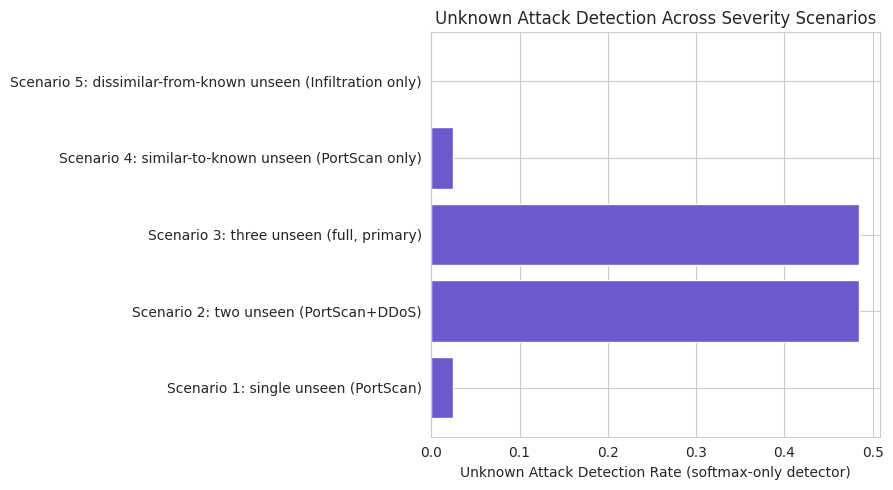

In [41]:
plt.figure(figsize=(9, 5))
plt.barh(severity_df["Scenario"], severity_df["UADR"], color="slateblue")
plt.xlabel("Unknown Attack Detection Rate (softmax-only detector)")
plt.title("Unknown Attack Detection Across Severity Scenarios")
plt.tight_layout()
plt.show()

ROBUSTNESS: FEATURE NOISE AND MISSING-DATA STRESS TESTS

Cell 41 — Gaussian noise injection

,NoiseSigma,UADR
0,0.00,0.5445
1,0.01,0.7883
2,0.05,0.8935
3,0.10,0.9501
4,0.20,0.9833


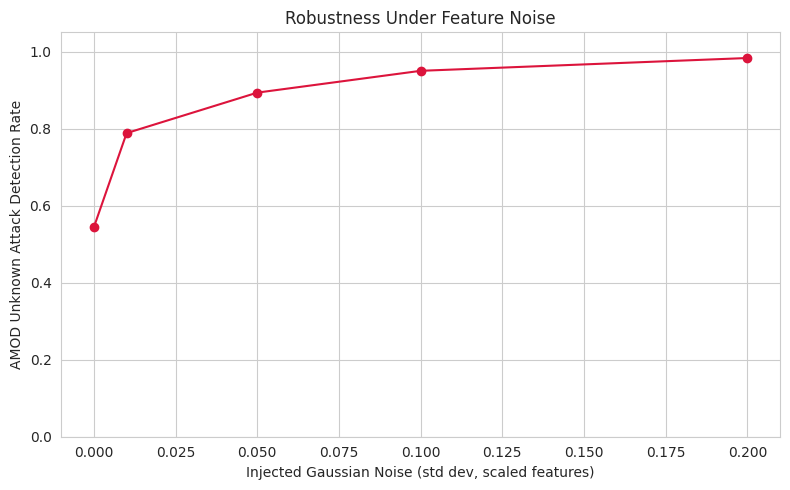

In [42]:
noise_levels = [0.0, 0.01, 0.05, 0.1, 0.2]
noise_results = []
for sigma in noise_levels:
    rng = np.random.RandomState(RANDOM_STATE)
    noisy_X_test = X_test_scaled + rng.normal(0, sigma, X_test_scaled.shape)

    conf_noisy = xgb_open.predict_proba(noisy_X_test).max(axis=1)
    ae_recon_noisy = autoencoder.predict(noisy_X_test, verbose=0)
    ae_err_noisy = np.mean(np.square(noisy_X_test - ae_recon_noisy), axis=1)
    bottleneck_noisy = encoder.predict(noisy_X_test, verbose=0)
    maha_noisy = mahalanobis_min_distance(bottleneck_noisy)
    iso_noisy = -iso_forest.decision_function(noisy_X_test)
    ent_noisy = prediction_entropy(xgb_open.predict_proba(noisy_X_test))

    sig = {
        "U": normalize_apply(1 - conf_noisy, *norm_ranges["U"]),
        "D": normalize_apply(maha_noisy, *norm_ranges["D"]),
        "A": normalize_apply(iso_noisy, *norm_ranges["A"]),
        "E": normalize_apply(ent_noisy, *norm_ranges["E"]),
    }
    score_noisy = amod_score(sig, AMOD_WEIGHTS)
    pred_noisy = (score_noisy > AMOD_THRESHOLD).astype(int)
    noise_results.append({"NoiseSigma": sigma, "UADR": recall_score(is_unseen_test, pred_noisy, zero_division=0)})

noise_df = pd.DataFrame(noise_results)
display(noise_df.round(4))

plt.figure(figsize=(8, 5))
plt.plot(noise_df["NoiseSigma"], noise_df["UADR"], marker="o", color="crimson")
plt.xlabel("Injected Gaussian Noise (std dev, scaled features)")
plt.ylabel("AMOD Unknown Attack Detection Rate")
plt.title("Robustness Under Feature Noise")
plt.ylim(0, 1.05); plt.tight_layout(); plt.show()

Cell 42 — Missing-data (feature dropout) stress test

Simulates sensor/logging gaps by randomly nulling out a fraction of feature values in the test set, then re-imputing with the TRAIN-derived median (the same statistic used throughout, so no leakage), and re-scoring.

,MissingFraction,UADR
0,0.00,0.5445
1,0.05,0.5465
2,0.10,0.5516
3,0.20,0.5649


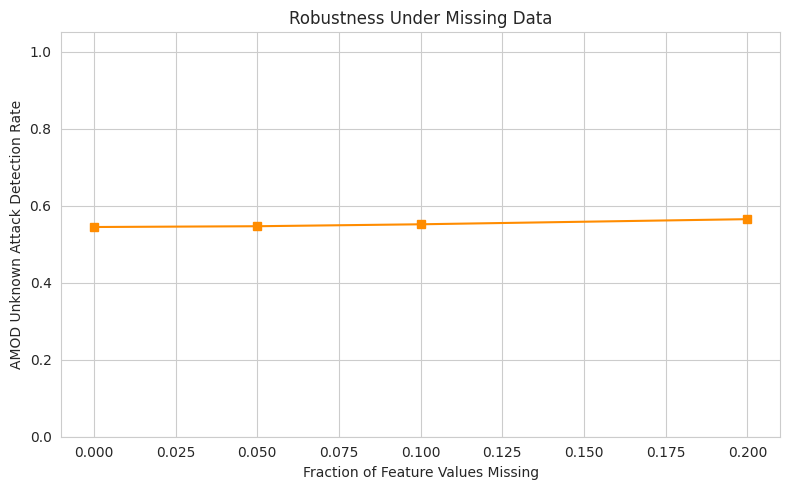

In [43]:
missingness_levels = [0.0, 0.05, 0.10, 0.20]
missing_results = []
rng = np.random.RandomState(RANDOM_STATE)

for frac in missingness_levels:
    X_test_missing_raw = X_test_raw.copy()
    if frac > 0:
        mask = rng.rand(*X_test_missing_raw.shape) < frac
        X_test_missing_raw = X_test_missing_raw.mask(mask)
    X_test_missing_imputed = X_test_missing_raw.fillna(train_median)
    X_test_missing_scaled = scaler.transform(X_test_missing_imputed)

    conf_m = xgb_open.predict_proba(X_test_missing_scaled).max(axis=1)
    ae_recon_m = autoencoder.predict(X_test_missing_scaled, verbose=0)
    ae_err_m = np.mean(np.square(X_test_missing_scaled - ae_recon_m), axis=1)
    bottleneck_m = encoder.predict(X_test_missing_scaled, verbose=0)
    maha_m = mahalanobis_min_distance(bottleneck_m)
    iso_m = -iso_forest.decision_function(X_test_missing_scaled)
    ent_m = prediction_entropy(xgb_open.predict_proba(X_test_missing_scaled))

    sig_m = {
        "U": normalize_apply(1 - conf_m, *norm_ranges["U"]),
        "D": normalize_apply(maha_m, *norm_ranges["D"]),
        "A": normalize_apply(iso_m, *norm_ranges["A"]),
        "E": normalize_apply(ent_m, *norm_ranges["E"]),
    }
    score_m = amod_score(sig_m, AMOD_WEIGHTS)
    pred_m = (score_m > AMOD_THRESHOLD).astype(int)
    missing_results.append({"MissingFraction": frac, "UADR": recall_score(is_unseen_test, pred_m, zero_division=0)})

missing_df = pd.DataFrame(missing_results)
display(missing_df.round(4))

plt.figure(figsize=(8, 5))
plt.plot(missing_df["MissingFraction"], missing_df["UADR"], marker="s", color="darkorange")
plt.xlabel("Fraction of Feature Values Missing")
plt.ylabel("AMOD Unknown Attack Detection Rate")
plt.title("Robustness Under Missing Data")
plt.ylim(0, 1.05); plt.tight_layout(); plt.show()

EXPLAINABILITY (SHAP)

Cell 43 — Global feature importance via SHAP on the closed-set Random Forest

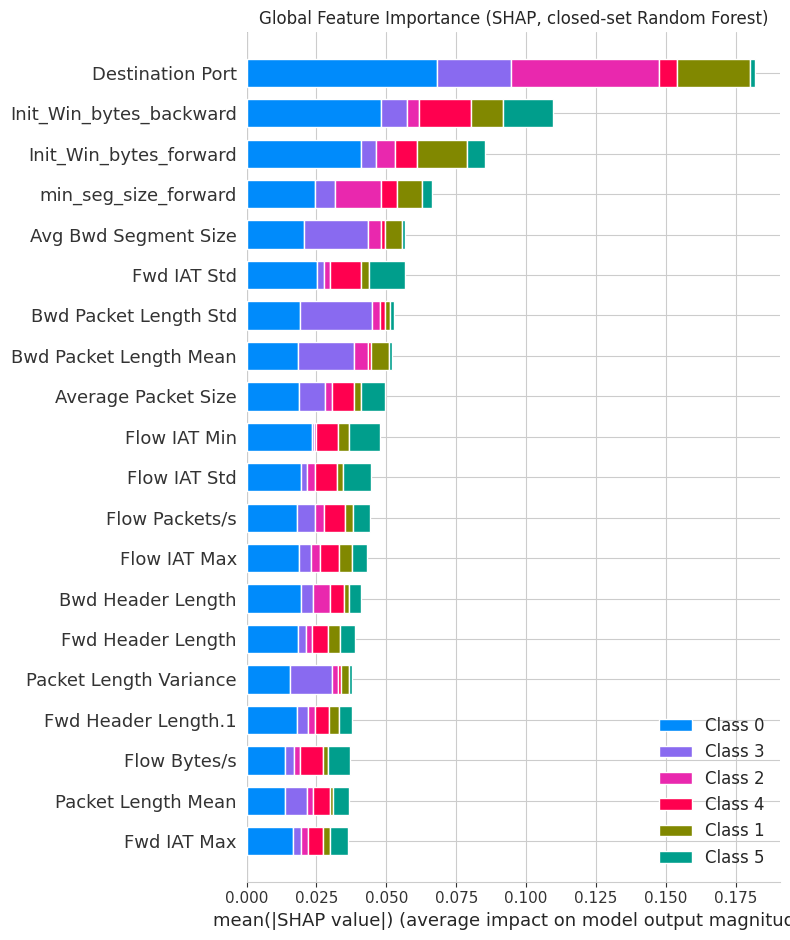

In [44]:
import shap

shap_background = X_train_scaled[np.random.RandomState(RANDOM_STATE).choice(len(X_train_scaled), 500, replace=False)]
shap_sample = X_test_scaled[np.random.RandomState(RANDOM_STATE).choice(len(X_test_scaled), 300, replace=False)]

explainer = shap.TreeExplainer(rf_closed)
shap_values = explainer.shap_values(shap_sample)

shap_values_for_plot = shap_values[1] if isinstance(shap_values, list) and len(shap_values) > 1 else shap_values
if isinstance(shap_values_for_plot, list):
    shap_values_for_plot = shap_values_for_plot[0]

plt.figure(figsize=(8, 7))
shap.summary_plot(shap_values_for_plot, shap_sample, feature_names=feature_cols, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP, closed-set Random Forest)")
plt.tight_layout()
plt.show()

Cell 44 — Why did AMOD flag a specific flow as unknown? Per-instance signal breakdown

In [50]:
example_idx = np.where((amod_pred_unknown == 1) & (is_unseen_test == 1))[0]
if len(example_idx) > 0:
    ex = example_idx[0]
    print("Example detected-unknown flow (test index", ex, "):")
    print("  True label:", df_test.iloc[ex]['label_norm'])
    print("  AMOD score:", round(test_amod_score[ex], 4), " (threshold =", round(AMOD_THRESHOLD, 4), ")")
    print("\n  Per-signal contribution (normalized value x adaptive weight):")
    for k in ["U", "D", "A", "E"]:
        contrib = signal_norm_test[k][ex] * AMOD_WEIGHTS[k]
        print(f"    {k}: normalized={signal_norm_test[k][ex]:.4f}  weight={AMOD_WEIGHTS[k]:.4f}  contribution={contrib:.4f}")
else:
    print("No true-positive unknown detections found in this run to illustrate.")

Example detected-unknown flow (test index 40453 ):
  True label: DDoS
  AMOD score: 0.2019  (threshold = 0.05 )

  Per-signal contribution (normalized value x adaptive weight):
    U: normalized=0.1904  weight=0.4505  contribution=0.0858
    D: normalized=0.0211  weight=0.0000  contribution=0.0000
    A: normalized=0.0890  weight=0.0991  contribution=0.0088
    E: normalized=0.2382  weight=0.4504  contribution=0.1073


COMPUTATIONAL EFFICIENCY

Cell 45 — Training time and per-sample inference latency for each model

Relevant to whether the proposed pipeline could plausibly run in or near real time.

In [45]:
def time_train(fit_fn):
    t0 = time.time()
    fit_fn()
    return time.time() - t0

def time_inference(predict_fn, n=1000):
    sample = X_test_scaled[:n]
    t0 = time.time()
    predict_fn(sample)
    elapsed = time.time() - t0
    return (elapsed / n) * 1000  # ms per sample

efficiency_rows = []

t_rf = time_train(lambda: RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train_scaled, y_train_cat))
lat_rf = time_inference(lambda x: rf_closed.predict(x))
efficiency_rows.append({"Model": "Random Forest (closed-set)", "Train Time (s)": t_rf, "Inference (ms/sample)": lat_rf})

lat_xgb = time_inference(lambda x: xgb_open.predict_proba(x))
efficiency_rows.append({"Model": "XGBoost (softmax detector)", "Train Time (s)": np.nan, "Inference (ms/sample)": lat_xgb})

lat_ae = time_inference(lambda x: autoencoder.predict(x, verbose=0))
efficiency_rows.append({"Model": "Autoencoder (reconstruction)", "Train Time (s)": np.nan, "Inference (ms/sample)": lat_ae})

lat_iso = time_inference(lambda x: iso_forest.decision_function(x))
efficiency_rows.append({"Model": "Isolation Forest", "Train Time (s)": np.nan, "Inference (ms/sample)": lat_iso})

def full_amod_inference(x):
    conf = xgb_open.predict_proba(x).max(axis=1)
    recon = autoencoder.predict(x, verbose=0)
    bott = encoder.predict(x, verbose=0)
    _ = mahalanobis_min_distance(bott)
    _ = iso_forest.decision_function(x)
    _ = prediction_entropy(xgb_open.predict_proba(x))

lat_amod_full = time_inference(full_amod_inference)
efficiency_rows.append({"Model": "Proposed AMOD (full pipeline)", "Train Time (s)": np.nan, "Inference (ms/sample)": lat_amod_full})

efficiency_df = pd.DataFrame(efficiency_rows)
display(efficiency_df.round(4))
print("\nNote: 'Train Time' is reported only where a fresh, isolated fit was timed in this cell;")
print("other models reuse earlier fits and only inference latency is newly measured here.")

,Model,Train Time (s),Inference (ms/sample)
0,Random Forest (closed-set),86.0194,0.0967
1,XGBoost (softmax detector),NaN,0.0361
2,Autoencoder (reconstruction),NaN,0.1534
3,Isolation Forest,NaN,0.0370
4,Proposed AMOD (full pipeline),NaN,0.3893



Note: 'Train Time' is reported only where a fresh, isolated fit was timed in this cell;
other models reuse earlier fits and only inference latency is newly measured here.


PUBLICATION FIGURES (SAVED AS PNG)

Figure 1 — UADR vs FPR trade-off (already generated above; saved here for the paper)

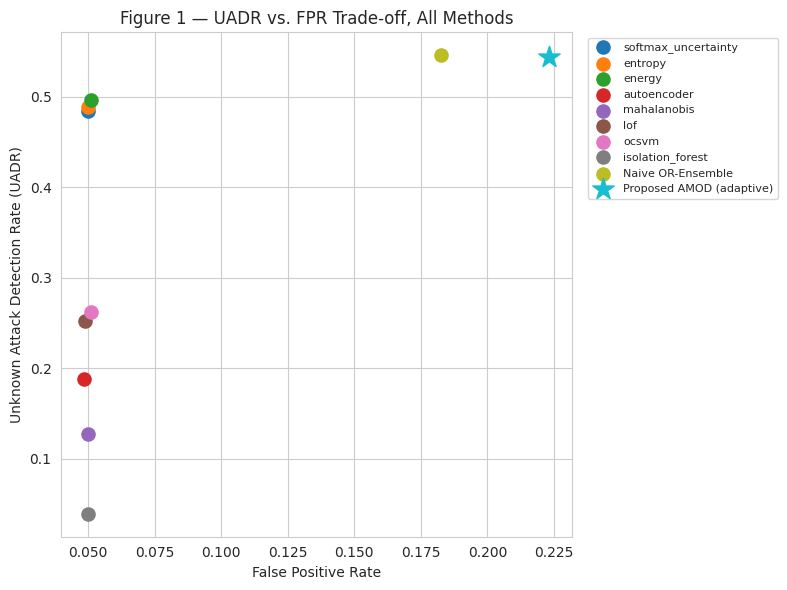

In [46]:
plt.figure(figsize=(8, 6))
for _, row in comprehensive_df.iterrows():
    marker = "*" if "AMOD" in row["Method"] else "o"
    size = 260 if "AMOD" in row["Method"] else 90
    plt.scatter(row["FPR"], row["UADR"], s=size, marker=marker, label=row["Method"])
plt.xlabel("False Positive Rate"); plt.ylabel("Unknown Attack Detection Rate (UADR)")
plt.title("Figure 1 — UADR vs. FPR Trade-off, All Methods")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("/content/figure1_uadr_fpr_tradeoff.png", dpi=200, bbox_inches="tight")
plt.show()

Figure 2 — Continual learning progression

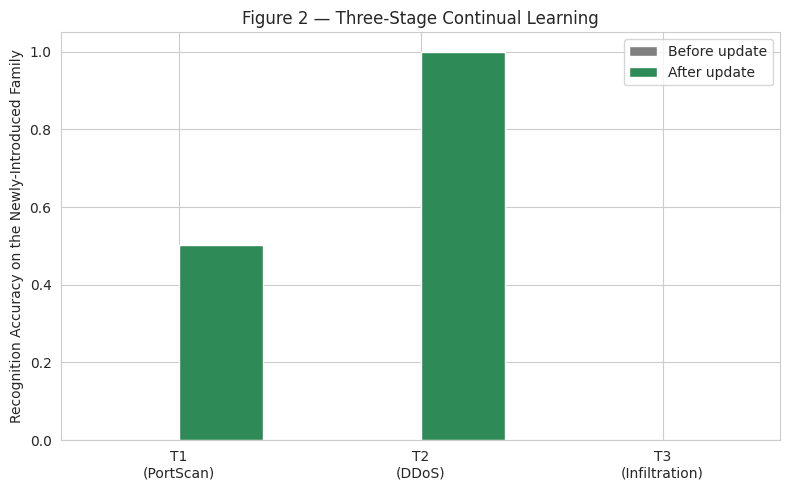

In [47]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(stage_df))
width = 0.35
ax.bar(x - width/2, stage_df["Accuracy Before Update"], width, label="Before update", color="gray")
ax.bar(x + width/2, stage_df["Accuracy After Update"], width, label="After update", color="seagreen")
ax.set_xticks(x); ax.set_xticklabels(stage_df["Stage"] + "\n(" + stage_df["Unseen Family Introduced"] + ")")
ax.set_ylabel("Recognition Accuracy on the Newly-Introduced Family")
ax.set_title("Figure 2 — Three-Stage Continual Learning")
ax.legend(); plt.tight_layout()
plt.savefig("/content/figure2_continual_learning.png", dpi=200, bbox_inches="tight")
plt.show()

Figure 3 — Component ablation

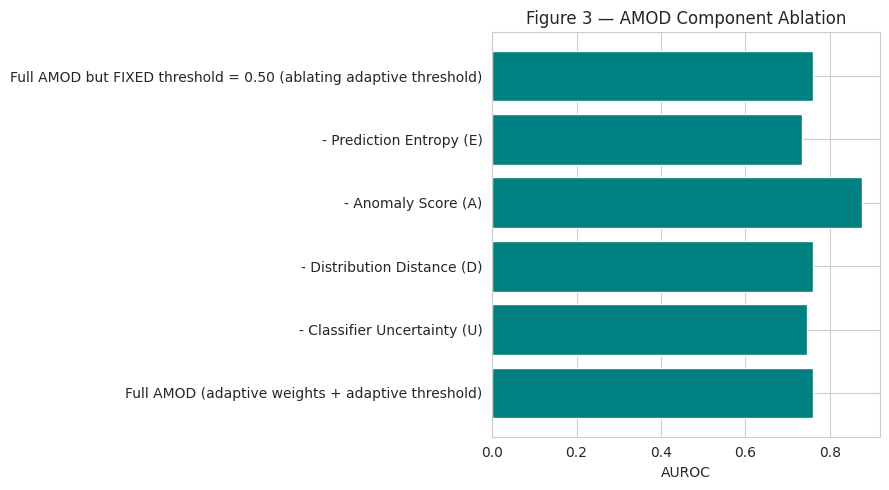

In [51]:
plt.figure(figsize=(9, 5))
plt.barh(component_ablation_df["Configuration"], component_ablation_df["AUROC"], color="teal")
plt.xlabel("AUROC"); plt.title("Figure 3 — AMOD Component Ablation")
plt.tight_layout()
plt.savefig("/content/figure3_component_ablation.png", dpi=200, bbox_inches="tight")
plt.show()

SAVE EVERYTHING

Cell 46 — Save all result tables and trained models

In [48]:
output_dir = "/content/project05_q1_results"
os.makedirs(output_dir, exist_ok=True)

comprehensive_df.to_csv(f"{output_dir}/comprehensive_method_comparison.csv", index=False)
individual_df.to_csv(f"{output_dir}/individual_detector_results.csv", index=False)
closed_set_df.to_csv(f"{output_dir}/closed_set_baselines.csv", index=False)
multiseed_df.to_csv(f"{output_dir}/multiseed_results.csv", index=False)
stage_df.to_csv(f"{output_dir}/continual_learning_stages.csv", index=False)
feature_ablation_df.to_csv(f"{output_dir}/feature_selection_ablation.csv", index=False)
component_ablation_df.to_csv(f"{output_dir}/amod_component_ablation.csv", index=False)
severity_df.to_csv(f"{output_dir}/severity_scenarios.csv", index=False)
noise_df.to_csv(f"{output_dir}/robustness_noise.csv", index=False)
missing_df.to_csv(f"{output_dir}/robustness_missingness.csv", index=False)
efficiency_df.to_csv(f"{output_dir}/computational_efficiency.csv", index=False)
purity_table.to_csv(f"{output_dir}/cluster_purity_table.csv")

import joblib
joblib.dump(rf_closed, f"{output_dir}/rf_closed.pkl")
joblib.dump(xgb_open, f"{output_dir}/xgb_open.pkl")
joblib.dump(svm_closed, f"{output_dir}/svm_closed.pkl")
joblib.dump(iso_forest, f"{output_dir}/iso_forest.pkl")
joblib.dump(ocsvm, f"{output_dir}/ocsvm.pkl")
joblib.dump(lof, f"{output_dir}/lof.pkl")
joblib.dump(scaler, f"{output_dir}/scaler.pkl")
joblib.dump(target_encoder, f"{output_dir}/target_encoder.pkl")
joblib.dump(AMOD_WEIGHTS, f"{output_dir}/amod_weights.pkl")
joblib.dump(AMOD_THRESHOLD, f"{output_dir}/amod_threshold.pkl")

print("All results and models saved to:", output_dir)

All results and models saved to: /content/project05_q1_results


Cell 47 — Final research summary

In [49]:
print("=" * 74)
print("PROJECT 05 — Q1-LEVEL FINAL RESEARCH SUMMARY")
print("=" * 74)
print("\nTitle: Adaptive Multi-Signal Open-World Detector (AMOD) for")
print("Zero-Day-Simulated Attack Detection on CIC-IDS2017")

print("\nTerminology: unseen-family withholding used to SIMULATE an open-world/zero-day")
print("condition — not a claim of literal never-before-seen real-world exploits.")

print("\nDataset: CIC-IDS2017,", len(df), "flows after leakage-safe stratified sampling")
print("Known classes (train):", known_classes)
print("Unseen families (primary scenario):", UNSEEN_FAMILIES_FULL)

print("\n--- Closed-set baselines (known / unseen / overall accuracy) ---")
print(closed_set_df.round(4).to_string(index=False))

print("\n--- Best individual open-set detector ---")
best_row = individual_df.sort_values('UADR', ascending=False).iloc[0]
print(best_row.to_string())

print("\n--- Proposed AMOD (adaptive weights + adaptive threshold) ---")
amod_row = comprehensive_df[comprehensive_df['Method'].str.contains('AMOD')].iloc[0]
print(amod_row.to_string())

print("\nAdaptive weights (data-driven, not hand-picked):", AMOD_WEIGHTS)
print("Adaptive threshold (leave-one-class-out pseudo-unseen, no test leakage):", round(AMOD_THRESHOLD, 4))

print("\nMulti-seed (5 seeds) lightweight-AMOD UADR: {:.2f}% +/- {:.2f}%".format(
    multiseed_df['UADR'].mean()*100, multiseed_df['UADR'].std()*100))
print("Wilcoxon signed-rank vs. softmax-only across seeds: statistic={:.3f}, p={:.4f}".format(wilcoxon_stat, wilcoxon_p))
print("McNemar's test, AMOD vs. best baseline ({}): statistic={:.3f}, p={:.4g}".format(
    best_baseline_name, mcnemar_result.statistic, mcnemar_result.pvalue))

print("\nUnknown-class discovery: auto-selected k =", BEST_K, " ARI =", round(ari, 4),
      " NMI =", round(nmi, 4), " purity =", round(purity, 4))

print("\nContinual learning (3-stage): accuracy on newly-introduced family after update:")
print(stage_df[["Stage", "Unseen Family Introduced", "Accuracy After Update"]].to_string(index=False))

print("\nTemporal (chronological) vs. random split, known-class accuracy:")
print("  Chronological split:", round(chrono_acc, 4))
print("  Random split (closed-set RF, known-only):", round(closed_set_df.iloc[0]['Known Acc'], 4))

print("\nRobustness: UADR at clean vs. noisiest (sigma=0.2):",
      round(noise_df.iloc[0]['UADR'], 4), "->", round(noise_df.iloc[-1]['UADR'], 4))
print("Robustness: UADR at 0% vs. 20% missing data:",
      round(missing_df.iloc[0]['UADR'], 4), "->", round(missing_df.iloc[-1]['UADR'], 4))

print("\n--- Explicit scope / future work ---")
print("Cross-corpus generalization (CIC-IDS2018, UNSW-NB15, ToN-IoT) was NOT run in this")
print("notebook and is left as documented future work, since it requires separate downloads")
print("and feature-schema harmonization beyond a single-dataset study.")
print("=" * 74)

PROJECT 05 — Q1-LEVEL FINAL RESEARCH SUMMARY

Title: Adaptive Multi-Signal Open-World Detector (AMOD) for
Zero-Day-Simulated Attack Detection on CIC-IDS2017

Terminology: unseen-family withholding used to SIMULATE an open-world/zero-day
condition — not a claim of literal never-before-seen real-world exploits.

Dataset: CIC-IDS2017, 180017 flows after leakage-safe stratified sampling
Known classes (train): ['Benign', 'Bot', 'Brute-Force', 'DoS', 'Web Attack ï¿½ Brute Force', 'Web Attack ï¿½ XSS']
Unseen families (primary scenario): ['PortScan', 'DDoS', 'Infiltration']

--- Closed-set baselines (known / unseen / overall accuracy) ---
        Model  Known Acc  Unseen Acc  Overall Acc
Random Forest     0.9981         0.0       0.6883
      XGBoost     0.9987         0.0       0.6887
      RBF-SVM     0.8358         0.0       0.5764

--- Best individual open-set detector ---
Detector       energy
UADR         0.496842
Precision    0.814311
F1           0.617142
FPR          0.050999
AUROC  